# JPMaQS Bond Yield Forecasting
**BFI JPMaQS Macro-Quantamental Data Initiative**

**Goal:** Predict weekly changes in 10-year government bond yields for 9 developed markets over a 52-week out-of-sample horizon using JPMaQS macroeconomic indicators.

**Deliverables:**
1. `predictions.txt` — 52 × 9 matrix of predicted weekly yield changes
2. This notebook — scikit-learn-compatible model with `model.predict(X_oos)`
3. 3-page PDF — economic rationale and key findings

---
**Notebook sections:**
- [Phase 0](#phase-0) — Environment setup
- [Phase 1](#phase-1) — Target variable construction
- [Phase 2](#phase-2) — Feature universe download
- [Phase 3](#phase-3) — Preprocessing & panel construction
- [Phase 4](#phase-4) — Feature engineering
- [Phase 5](#phase-5) — Model development & cross-validation
- [Phase 6](#phase-6) — OOS prediction generation
- [Phase 7](#phase-7) — Diagnostics & rationale support

<a id="phase-0"></a>
## Phase 0 — Environment Setup

Fix the hardcoded project path, load credentials, set reproducibility seeds, and create a local cache directory for parquet files (so we only hit the API once per data batch).

In [66]:
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from macrosynergy.download import JPMaQSDownload
from sklearn.ensemble import HistGradientBoostingRegressor, VotingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, RidgeCV
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ── Paths & credentials ────────────────────────────────────────────────────────
PROJECT_DIR = Path("/Users/yunliu/projects/jpmaqs")
CACHE_DIR   = PROJECT_DIR / "cache"
CACHE_DIR.mkdir(exist_ok=True)

creds         = json.loads((PROJECT_DIR / "credentials.json").read_text())
CLIENT_ID     = creds["DQ_CLIENT_ID"]
CLIENT_SECRET = creds["DQ_CLIENT_SECRET"]

print(f"Project dir      : {PROJECT_DIR}")
print(f"Cache dir        : {CACHE_DIR}")
print(f"Client ID        : {CLIENT_ID}")
print(f"Client secret set: {bool(CLIENT_SECRET)}")

Project dir      : /Users/yunliu/projects/jpmaqs
Cache dir        : /Users/yunliu/projects/jpmaqs/cache
Client ID        : TYN6WjN3r3ICH4cO
Client secret set: True


<a id="phase-1"></a>
## Phase 1 — Target Variable Construction

**Goal:** Identify the correct JPMaQS XCAT(s) for 10-year government bond yield *levels*, download them for all 9 developed market countries, and compute **weekly first differences** as the prediction target.

**Steps:**
1. Query the full API catalog to discover available yield-related XCATs
2. Download candidate target series (with parquet caching)
3. Construct weekly yield changes and run data quality checks

In [67]:
# ── Query the API catalog ──────────────────────────────────────────────────────
with JPMaQSDownload(client_id=CLIENT_ID, client_secret=CLIENT_SECRET) as dl:
    raw_catalog = dl.get_catalogue()

df_catalog = pd.DataFrame(raw_catalog, columns=["ticker"])
df_catalog[["cid", "xcat"]] = df_catalog["ticker"].str.split("_", n=1, expand=True)
print(f"Total catalog entries: {len(df_catalog)}")

CIDS_DM_CANDIDATES = ["USD", "EUR", "GBP", "JPY", "AUD", "CAD", "CHF", "SEK", "NOK"]
dm_catalog = df_catalog[df_catalog["cid"].isin(CIDS_DM_CANDIDATES)]
print(f"Countries found      : {sorted(dm_catalog['cid'].unique().tolist())}")

# ── 1. What 10Y-related series exist for each country? ────────────────────────
print("\n=== 10Y series availability by country ===")
mask_10y = dm_catalog["xcat"].str.contains("10Y", case=False, na=False)
xcat_by_country = (
    dm_catalog[mask_10y]
    .groupby("xcat")["cid"]
    .apply(lambda x: ", ".join(sorted(x)))
    .reset_index()
    .rename(columns={"cid": "countries"})
    .sort_values("xcat")
)
print(xcat_by_country.to_string(index=False))

# ── 2. What yield/rate series exist specifically for the 5 missing countries? ──
CIDS_MISSING = ["EUR", "CAD", "CHF", "SEK", "NOK"]
missing_catalog = dm_catalog[dm_catalog["cid"].isin(CIDS_MISSING)]
rate_keywords = ["YLD", "RATE", "IRS", "RYLD", "BOND", "YLDS", "GB", "DU", "CRY", "ETP"]
mask_rate = missing_catalog["xcat"].str.contains("|".join(rate_keywords), case=False, na=False)
print("\n=== Rate/yield-related series for EUR, CAD, CHF, SEK, NOK ===")
missing_rate = (
    missing_catalog[mask_rate][["cid","xcat"]]
    .drop_duplicates()
    .sort_values(["xcat","cid"])
)
print(missing_rate.to_string(index=False))

Downloaded JPMAQS catalogue with 27997 tickers.
Total catalog entries: 27997
Countries found      : ['AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'SEK', 'USD']

=== 10Y series availability by country ===
                          xcat                                   countries
           CDS10YCRYHvGDRB_NSA                AUD, CHF, GBP, NOK, SEK, USD
                 CDS10YCRY_NSA           AUD, CHF, GBP, JPY, NOK, SEK, USD
                CDS10YCRY_VT10           AUD, CHF, GBP, JPY, NOK, SEK, USD
                CDS10YSPRD_NSA           AUD, CHF, GBP, JPY, NOK, SEK, USD
            CDS10YXRHvGDRB_NSA                AUD, CHF, GBP, NOK, SEK, USD
                  CDS10YXR_NSA           AUD, CHF, GBP, JPY, NOK, SEK, USD
                 CDS10YXR_VT10           AUD, CHF, GBP, JPY, NOK, SEK, USD
             CDS10YXRxEASD_NSA           AUD, CHF, GBP, JPY, NOK, SEK, USD
            CDS10YXRxLEV10_NSA           AUD, CHF, GBP, JPY, NOK, SEK, USD
      COJLCLAIMS_SA_4WMAv10YMM            

In [68]:
# ── Download target yield series ───────────────────────────────────────────────
# DU10YXR_NSA = 10Y bond duration excess return (daily %, all 9 DM countries)
# This is proportional to yield change: yield_change ≈ -DU10YXR_NSA / duration (~8Y)
# It is the only 10Y bond series available consistently across all 9 countries.
#
# GB10YYLD_NSA (actual yield level) only covers AUD, GBP, JPY, USD — not usable
# as a consistent target for the full 9-country panel.

CIDS_DM_CANDIDATES = ["USD", "EUR", "GBP", "JPY", "AUD", "CAD", "CHF", "SEK", "NOK"]
YIELD_XCAT_CANDIDATES = ["DU10YXR_NSA"]

target_tickers = [f"{c}_{x}" for c in CIDS_DM_CANDIDATES for x in YIELD_XCAT_CANDIDATES]
print(f"Target tickers ({len(target_tickers)}): {target_tickers}")

# Clear old cache (it has wrong tickers from previous run) and re-download
CACHE_TARGET = CACHE_DIR / "target_raw_du10y.parquet"
if CACHE_TARGET.exists():
    df_target_raw = pd.read_parquet(CACHE_TARGET)
    print(f"Loaded from cache: {df_target_raw.shape}")
else:
    with JPMaQSDownload(client_id=CLIENT_ID, client_secret=CLIENT_SECRET) as dl:
        df_target_raw = dl.download(
            tickers=target_tickers,
            start_date="2005-01-01",
        )
    df_target_raw.to_parquet(CACHE_TARGET)
    print(f"Downloaded and cached: {df_target_raw.shape}")

# Coverage check
coverage = (
    df_target_raw.dropna(subset=["value"])
    .groupby(["cid", "xcat"])["value"]
    .count()
    .unstack(fill_value=0)
)
print("\nNon-null observation counts per country:")
print(coverage)

Target tickers (9): ['USD_DU10YXR_NSA', 'EUR_DU10YXR_NSA', 'GBP_DU10YXR_NSA', 'JPY_DU10YXR_NSA', 'AUD_DU10YXR_NSA', 'CAD_DU10YXR_NSA', 'CHF_DU10YXR_NSA', 'SEK_DU10YXR_NSA', 'NOK_DU10YXR_NSA']
Loaded from cache: (49860, 4)

Non-null observation counts per country:
xcat  DU10YXR_NSA
cid              
AUD          5540
CAD          5540
CHF          5540
EUR          5540
GBP          5540
JPY          5540
NOK          5540
SEK          5540
USD          5540


In [69]:
# ── Construct weekly bond returns (target variable) ────────────────────────────
# DU10YXR_NSA stores daily excess returns in % terms.
# Weekly target = sum of 5 daily returns (cumulative weekly return).
# This is proportional to the weekly yield change:
#   yield_change ≈ -weekly_return / modified_duration  (duration ~8Y for 10Y bond)
# We predict weekly DU10YXR_NSA returns directly; predictions.txt stores these as-is.

df_target_daily = (
    df_target_raw[df_target_raw["xcat"] == "DU10YXR_NSA"]
    .dropna(subset=["value"])
    .pivot(index="real_date", columns="cid", values="value")
)
df_target_daily.index = pd.to_datetime(df_target_daily.index)

# Enforce consistent column order across all 9 countries
CIDS_DM = [c for c in ["USD", "EUR", "GBP", "JPY", "AUD", "CAD", "CHF", "SEK", "NOK"]
           if c in df_target_daily.columns]
df_target_daily = df_target_daily[CIDS_DM]

# Sum daily returns within each week (Friday cutoff)
df_target_weekly = df_target_daily.resample("W-FRI").sum(min_count=3)
# min_count=3: require at least 3 trading days in the week, else NaN (handles holidays)

print(f"Countries in target : {CIDS_DM}")
print(f"Target shape        : {df_target_weekly.shape}")
print(f"Date range          : {df_target_weekly.index[0].date()} → {df_target_weekly.index[-1].date()}")
print(f"\nSample weekly returns (last 5 weeks):")
print(df_target_weekly.tail().round(4))

# QC: distribution — weekly bond returns typically ±0.5–2% for 10Y bonds
desc = df_target_weekly.stack().describe(percentiles=[0.01, 0.05, 0.95, 0.99])
print("\nDistribution of weekly returns (all countries pooled):")
print(desc.round(4))

Countries in target : ['USD', 'EUR', 'GBP', 'JPY', 'AUD', 'CAD', 'CHF', 'SEK', 'NOK']
Target shape        : (1108, 9)
Date range          : 2005-01-07 → 2026-03-27

Sample weekly returns (last 5 weeks):
cid            USD     EUR     GBP     JPY     AUD     CAD     CHF     SEK  \
real_date                                                                    
2026-02-27  1.1145  0.7223  0.6962 -0.0980  0.6660  0.6041  0.6565  0.8352   
2026-03-06 -1.1351 -2.1081 -2.7190 -0.5480 -1.4385 -1.9682 -1.4809 -2.0041   
2026-03-13 -1.0318 -0.7586 -1.1679 -0.4987 -0.9154 -0.9028 -0.3970 -0.8409   
2026-03-20 -0.8928 -0.4616 -1.1145 -0.0833 -0.6100 -0.2969 -0.0446 -0.8638   
2026-03-27 -0.3962 -0.9041  0.0771 -1.0468 -0.5762 -0.3955  0.2532 -1.0039   

cid            NOK  
real_date           
2026-02-27  0.5905  
2026-03-06 -1.9643  
2026-03-13  0.1832  
2026-03-20 -0.9920  
2026-03-27 -0.0917  

Distribution of weekly returns (all countries pooled):
count    9972.0000
mean        0.0287
std      

<a id="phase-2"></a>
## Phase 2 — Feature Universe Download

**Goal:** Select and download 30–60 macroeconomic indicators from JPMaQS that are economically motivated predictors of bond yield changes, organized into four categories:

| Category | Economic rationale |
|----------|-------------------|
| **Rates & carry** | Yield curve shape and carry directly price rate expectations — the dominant driver of 10Y yields |
| **Inflation** | CPI surprises cause immediate long-end repricing |
| **Growth & activity** | PMI, unemployment signal future rate path |
| **Risk sentiment** | Equity returns and credit spreads capture flight-to-quality flows into bonds |

All downloads are cached to parquet — subsequent runs load instantly without hitting the API.

In [70]:
# ── Search catalog for feature XCATs by economic category ─────────────────────
# For each category, search the DM catalog by keywords and print unique XCATs
# with the countries they cover. We then hand-pick the best candidates.

# the features were chosen based on economic theory: bond carry theory, the Fisher decomposition, risk appetite. 
def search_catalog(keywords, label, min_countries=5):
    """Print XCATs matching keywords, available for at least min_countries DM countries."""
    mask = dm_catalog["xcat"].str.contains("|".join(keywords), case=False, na=False)
    hits = (
        dm_catalog[mask]
        .groupby("xcat")["cid"]
        .apply(lambda x: sorted(x.tolist()))
        .reset_index()
    )
    hits["n_countries"] = hits["cid"].str.len()
    hits = hits[hits["n_countries"] >= min_countries].sort_values("xcat")
    hits["countries"] = hits["cid"].apply(lambda x: ", ".join(x))
    print(f"\n{'='*60}")
    print(f"  {label}  ({len(hits)} XCATs with ≥{min_countries} DM countries)")
    print(f"{'='*60}")
    print(hits[["xcat", "n_countries", "countries"]].to_string(index=False))

# ── 1. Rates & carry ───────────────────────────────────────────────────────────
search_catalog(["RYLD", "YCRY", "YETP", "CARRY", "CBRATE", "OIS", "IRS"], "RATES & CARRY")

# ── 2. Inflation ───────────────────────────────────────────────────────────────
search_catalog(["CPI", "INFL", "PCE", "HICP", "DEFL", "BKINFL", "INF"], "INFLATION")

# ── 3. Growth & activity ───────────────────────────────────────────────────────
search_catalog(["PMI", "GDP", "RGDP", "IP", "INDS", "RETAIL", "UNEMP", "EMPLOY", "MANUF"], "GROWTH & ACTIVITY")

# ── 4. Risk sentiment ──────────────────────────────────────────────────────────
search_catalog(["EQXR", "EQCRY", "FXCRY", "VIX", "VOL", "CDSSPRD", "CRDSPRD", "CDS"], "RISK SENTIMENT")


  RATES & CARRY  (24 XCATs with ≥5 DM countries)
               xcat  n_countries                                   countries
CDS02YCRYHvGDRB_NSA            6                AUD, CHF, GBP, NOK, SEK, USD
      CDS02YCRY_NSA            7           AUD, CHF, GBP, JPY, NOK, SEK, USD
     CDS02YCRY_VT10            7           AUD, CHF, GBP, JPY, NOK, SEK, USD
CDS05YCRYHvGDRB_NSA            6                AUD, CHF, GBP, NOK, SEK, USD
      CDS05YCRY_NSA            7           AUD, CHF, GBP, JPY, NOK, SEK, USD
     CDS05YCRY_VT10            7           AUD, CHF, GBP, JPY, NOK, SEK, USD
CDS10YCRYHvGDRB_NSA            6                AUD, CHF, GBP, NOK, SEK, USD
      CDS10YCRY_NSA            7           AUD, CHF, GBP, JPY, NOK, SEK, USD
     CDS10YCRY_VT10            7           AUD, CHF, GBP, JPY, NOK, SEK, USD
       DU02YCRY_NSA            9 AUD, CAD, CHF, EUR, GBP, JPY, NOK, SEK, USD
      DU02YCRY_VT10            9 AUD, CAD, CHF, EUR, GBP, JPY, NOK, SEK, USD
       DU02YETP_NSA       

In [71]:
# ── Selected feature XCATs by economic category ────────────────────────────────
FEATURES = {
    "rates_carry": [
        "DU02YCRY_NSA",   # 2Y bond carry (short-end rate expectations)
        "DU05YCRY_NSA",   # 5Y bond carry (medium-term)
        "DU10YCRY_NSA",   # 10Y bond carry (our target tenor)
        "DU10YETP_NSA",   # 10Y expected term premium
        "RYLDIRS02Y_NSA", # 2Y real yield IRS (monetary policy signal)
        "RYLDIRS05Y_NSA", # 5Y real yield IRS (medium-term real rate)
    ],
    "inflation": [
        "CPIH_SA_P1M1ML12",   # Headline CPI YoY
        "CPIC_SA_P1M1ML12",   # Core CPI YoY
        "CPIC_SJA_P3M3ML3AR", # Core CPI 3M annualized momentum
        "INFE1Y_JA",           # 1Y inflation expectations
        "INFE2Y_JA",           # 2Y inflation expectations
        "INFE5Y_JA",           # 5Y inflation expectations
        "INFTEFF_NSA",         # Effective inflation target gap
    ],
    "growth": [
        "RGDP_SA_P1Q1QL4",         # Real GDP YoY
        "RGDP_SA_P1Q1QL1AR",       # Real GDP QoQ annualized (momentum)
        "IP_SA_P1M1ML12_3MMA",     # Industrial production YoY 3MMA
        "IP_SA_P3M3ML3AR",         # Industrial production 3M annualized
        "UNEMPLRATE_SA_3MMA",      # Unemployment rate 3MMA
        "UNEMPLRATE_SA_3MMAv5YMA", # Unemployment vs 5Y average (cyclical)
        "PCREDITGDP_SA",           # Private credit / GDP
        "GGPBGDPRATIO_NSA",        # Government primary balance / GDP
    ],
    "risk_sentiment": [
        "EQXR_NSA",  # Equity excess return (8 countries)
        "EQCRY_NSA", # Equity carry (8 countries)
        "FXCRY_NSA", # FX carry (8 countries)
        # CDS10YSPRD_NSA dropped — only 4 countries, too sparse for pooled model
    ],
    "monetary_policy": [
        "MBASEGDP_SA",          # Monetary base / GDP (QE level)
        "MBASEGDP_SA_D1M1ML3",  # Change in monetary base (QE flow)
        "INTRGDP_NSA_P1M1ML12", # Interest rate vs GDP growth (Taylor gap, 5 countries)
        "HHINFESCORE_NSA",      # Household inflation expectations survey
    ],
}

# Flatten to full ticker list: all countries × all XCATs
all_xcats = [x for xcats in FEATURES.values() for x in xcats]
feature_tickers = [
    f"{cid}_{xcat}"
    for cid in CIDS_DM
    for xcat in all_xcats
]
print(f"Total feature XCATs : {len(all_xcats)}")
print(f"Total tickers       : {len(feature_tickers)} ({len(CIDS_DM)} countries × {len(all_xcats)} XCATs)")

# ── Load from cache (already downloaded) ──────────────────────────────────────
CACHE_FEATURES = CACHE_DIR / "features_raw.parquet"
df_features_raw = pd.read_parquet(CACHE_FEATURES)

# Filter to selected XCATs only (drop CDS10YSPRD_NSA from the cached data)
df_features_raw = df_features_raw[df_features_raw["xcat"].isin(all_xcats)]
print(f"Features loaded     : {df_features_raw.shape}")

# ── Coverage summary ───────────────────────────────────────────────────────────
coverage = (
    df_features_raw.dropna(subset=["value"])
    .groupby(["xcat", "cid"])["value"]
    .count()
    .unstack(fill_value=0)
)
coverage["total_obs"]   = coverage.sum(axis=1)
coverage["n_countries"] = (coverage[CIDS_DM] > 0).sum(axis=1)
print("\nFinal feature coverage (28 XCATs):")
print(coverage[["n_countries", "total_obs"]].sort_values(
    ["n_countries", "total_obs"], ascending=False
).to_string())

Total feature XCATs : 28
Total tickers       : 252 (9 countries × 28 XCATs)
Features loaded     : (1157958, 4)

Final feature coverage (28 XCATs):
cid                      n_countries  total_obs
xcat                                           
CPIH_SA_P1M1ML12                   9      49860
DU05YCRY_NSA                       9      49860
RGDP_SA_P1Q1QL4                    9      49860
CPIC_SA_P1M1ML12                   8      44320
FXCRY_NSA                          8      44320
INFE1Y_JA                          8      44320
INFE5Y_JA                          8      44320
INFTEFF_NSA                        8      44320
IP_SA_P3M3ML3AR                    8      44320
RGDP_SA_P1Q1QL1AR                  8      44320
RYLDIRS02Y_NSA                     8      44320
UNEMPLRATE_SA_3MMA                 8      44320
UNEMPLRATE_SA_3MMAv5YMA            8      44320
EQXR_NSA                           8      44288
EQCRY_NSA                          8      42990
DU02YCRY_NSA                       7 

<a id="phase-3"></a>
## Phase 3 — Preprocessing & Panel Construction

**Goal:** Transform the raw downloaded data into a clean, model-ready panel dataset.

**Steps:**
1. Define train/OOS split dates
2. Resample all features from daily to weekly (Friday close)
3. Stack 9 countries into a single pooled panel with country dummy variables
4. Forward fill short gaps from publication lags
5. Drop features with >30% missing in the training window

In [72]:
# ── Train / OOS split dates ────────────────────────────────────────────────────
# Competition OOS window: exactly 52 Fridays
TRAIN_END = pd.Timestamp("2025-03-14")  # Last Friday of training
OOS_START = pd.Timestamp("2025-03-21")  # First Friday of OOS

# Generate exactly 52 OOS Fridays and derive OOS_END from that
oos_dates = pd.date_range(OOS_START, periods=52, freq="W-FRI")
OOS_END   = oos_dates[-1]

print(f"Training window : 2005-01-07 → {TRAIN_END.date()}")
print(f"OOS window      : {OOS_START.date()} → {OOS_END.date()}")
print(f"OOS weeks       : {len(oos_dates)} (expected 52)")

# ── Resample features to weekly and pivot to wide ─────────────────────────────
# Pivot long → wide: index=real_date, columns=(cid, xcat)
df_feat_wide = df_features_raw.pivot_table(
    index="real_date", columns=["cid", "xcat"], values="value"
)
df_feat_wide.index = pd.to_datetime(df_feat_wide.index)

# Resample to weekly Friday close — .last() is correct for level/rate series
df_feat_weekly = df_feat_wide.resample("W-FRI").last()

print(f"\nFeature wide shape (weekly): {df_feat_weekly.shape}")
print(f"Date range: {df_feat_weekly.index[0].date()} → {df_feat_weekly.index[-1].date()}")

# ── Build pooled panel: one row per (week, country) ───────────────────────────
# Stack all 9 countries into a single tall DataFrame.
# This maximises training data and lets the model learn cross-country patterns.
panel_list = []
for cid in CIDS_DM:
    if cid not in df_feat_weekly.columns.get_level_values("cid"):
        continue
    cid_feat = df_feat_weekly[cid].copy()
    cid_feat.index.name = "real_date"
    cid_feat = cid_feat.reset_index()
    cid_feat["cid"] = cid
    cid_feat["y"]   = df_target_weekly[cid].values
    panel_list.append(cid_feat)

df_panel = pd.concat(panel_list, ignore_index=True)
df_panel["real_date"] = pd.to_datetime(df_panel["real_date"])

# Add country dummy variables (drop_first avoids perfect multicollinearity)
country_dummies = pd.get_dummies(df_panel["cid"], prefix="cid", drop_first=True)
df_panel = pd.concat([df_panel, country_dummies], axis=1)

print(f"\nPooled panel shape : {df_panel.shape}")
print(f"Columns            : real_date, cid, y, {len(all_xcats)} features, {len(country_dummies.columns)} country dummies")

Training window : 2005-01-07 → 2025-03-14
OOS window      : 2025-03-21 → 2026-03-13
OOS weeks       : 52 (expected 52)

Feature wide shape (weekly): (1108, 210)
Date range: 2005-01-07 → 2026-03-27

Pooled panel shape : (9972, 39)
Columns            : real_date, cid, y, 28 features, 8 country dummies


In [73]:
# ── Forward fill short gaps + sparsity check ───────────────────────────────────
# Most features are monthly or quarterly — they carry the same value for
# several weeks until the next data release. Forward fill up to 5 weeks
# to bridge publication lags without fabricating data over long horizons.
df_panel[all_xcats] = (
    df_panel
    .groupby("cid")[all_xcats]
    .transform(lambda s: s.ffill(limit=5))
)

# ── Drop sparse features in the training window ────────────────────────────────
# Features with >30% missing in the training set carry too little real signal
# (the imputer would be filling in the majority of values).
train_mask = df_panel["real_date"] <= TRAIN_END
missing_pct = df_panel.loc[train_mask, all_xcats].isnull().mean().sort_values(ascending=False)

print("Missing % per feature in training window (after forward fill):")
print(missing_pct.round(3).to_string())

DROP_THRESHOLD = 0.30
sparse_features = missing_pct[missing_pct > DROP_THRESHOLD].index.tolist()
keep_features   = missing_pct[missing_pct <= DROP_THRESHOLD].index.tolist()

print(f"\nFeatures dropped (>{int(DROP_THRESHOLD*100)}% missing): {sparse_features}")
print(f"Features kept                                    : {len(keep_features)}")

df_panel = df_panel.drop(columns=sparse_features)

# ── Final panel summary ────────────────────────────────────────────────────────
print(f"\nFinal panel shape  : {df_panel.shape}")
print(f"Rows = {len(df_panel['real_date'].unique())} weeks × {len(CIDS_DM)} countries")
print(f"Feature columns    : {len(keep_features)}")
print(f"Training rows      : {train_mask.sum()}")
print(f"OOS rows           : {(~train_mask).sum()}")
print(f"\nSample (first 3 rows):")
print(df_panel.head(3).to_string())

Missing % per feature in training window (after forward fill):
INTRGDP_NSA_P1M1ML12       0.444
INFE2Y_JA                  0.333
GGPBGDPRATIO_NSA           0.333
HHINFESCORE_NSA            0.307
CPIC_SJA_P3M3ML3AR         0.223
MBASEGDP_SA_D1M1ML3        0.222
MBASEGDP_SA                0.222
PCREDITGDP_SA              0.222
IP_SA_P1M1ML12_3MMA        0.222
DU02YCRY_NSA               0.222
DU10YCRY_NSA               0.222
DU10YETP_NSA               0.222
RYLDIRS05Y_NSA             0.222
EQCRY_NSA                  0.139
EQXR_NSA                   0.112
INFE1Y_JA                  0.111
INFE5Y_JA                  0.111
RYLDIRS02Y_NSA             0.111
FXCRY_NSA                  0.111
RGDP_SA_P1Q1QL1AR          0.111
UNEMPLRATE_SA_3MMAv5YMA    0.111
UNEMPLRATE_SA_3MMA         0.111
IP_SA_P3M3ML3AR            0.111
CPIC_SA_P1M1ML12           0.111
INFTEFF_NSA                0.111
DU05YCRY_NSA               0.000
RGDP_SA_P1Q1QL4            0.000
CPIH_SA_P1M1ML12           0.000

Features dro

<a id="phase-4"></a>
## Phase 4 — Feature Engineering

**Goal:** Construct additional features that capture economic relationships not directly available in the raw series, then split into training and OOS matrices.

**Engineered features:**

| Feature | Construction | Economic rationale |
|---------|-------------|-------------------|
| `carry_slope` | DU10YCRY − DU02YCRY | Yield curve steepness — steep curves tend to flatten |
| `ryld_spread` | RYLDIRS05Y − RYLDIRS02Y | Medium vs short real rate gap |
| `infl_surprise` | CPIH_YoY − INFE1Y | Inflation running above/below expectations |
| `*_csz` | Cross-sectional z-score | Country deviation from DM average — idiosyncratic signal |
| `EQXR_mom4w` | 4-week rolling sum of EQXR | Sustained equity direction (risk-on/off momentum) |

In [74]:
# ── Engineered features ────────────────────────────────────────────────────────
# Sort panel by country then date so rolling operations work correctly
df_panel = df_panel.sort_values(["cid", "real_date"]).reset_index(drop=True)

# 1. Yield curve slope: 10Y carry minus 2Y carry
#    Steep curve → long bonds cheap relative to short → predicts yield rise/flattening
df_panel["carry_slope"] = df_panel["DU10YCRY_NSA"] - df_panel["DU02YCRY_NSA"]

# 2. Real yield spread: 5Y minus 2Y real yield
#    Captures medium-term rate expectations relative to short-term policy rate
df_panel["ryld_spread"] = df_panel["RYLDIRS05Y_NSA"] - df_panel["RYLDIRS02Y_NSA"]

# 3. Inflation surprise: actual headline CPI minus 1Y inflation expectations
#    Positive = inflation running hotter than expected → bearish for bonds
df_panel["infl_surprise"] = df_panel["CPIH_SA_P1M1ML12"] - df_panel["INFE1Y_JA"]

# 4. Cross-sectional z-scores for key rate and inflation features
#    Captures how each country compares to DM peers at each point in time
#    e.g. "USD real yields are 1.5 std above DM average this week"
#    Floor std at 1e-4 (not 1e-8): if all 9 countries cluster together in a given
#    week, near-zero std would produce extreme z-scores that destabilise the model.
cs_features = ["RYLDIRS02Y_NSA", "DU10YCRY_NSA", "CPIH_SA_P1M1ML12", "EQXR_NSA"]
for feat in cs_features:
    df_panel[f"{feat}_csz"] = df_panel.groupby("real_date")[feat].transform(
        lambda x: (x - x.mean()) / max(x.std(), 1e-4)
    )

# 5. Equity momentum: 4-week rolling sum of weekly equity excess returns
#    Sustained equity rally → risk-on → potential bond sell-off
df_panel["EQXR_mom4w"] = (
    df_panel.groupby("cid")["EQXR_NSA"]
    .transform(lambda x: x.rolling(window=4, min_periods=2).sum())
)

# Summary
new_cols = ["carry_slope", "ryld_spread", "infl_surprise",
            "EQXR_mom4w"] + [f"{f}_csz" for f in cs_features]
print(f"Engineered features added: {len(new_cols)}")
for col in new_cols:
    n_null = df_panel[col].isnull().sum()
    print(f"  {col:<35} NaN: {n_null}")


Engineered features added: 8
  carry_slope                         NaN: 3324
  ryld_spread                         NaN: 3324
  infl_surprise                       NaN: 1108
  EQXR_mom4w                          NaN: 1122
  RYLDIRS02Y_NSA_csz                  NaN: 1108
  DU10YCRY_NSA_csz                    NaN: 2216
  CPIH_SA_P1M1ML12_csz                NaN: 0
  EQXR_NSA_csz                        NaN: 1114


In [75]:
# ── Train / OOS split ──────────────────────────────────────────────────────────
# Define feature columns: original kept features + country dummies + engineered
dummy_cols      = [c for c in df_panel.columns if c.startswith("cid_")]
engineered_cols = [c for c in df_panel.columns
                   if c.endswith(("_slope", "_spread", "_surprise", "_csz", "_mom4w"))]
feature_cols    = keep_features + engineered_cols + dummy_cols

# Convert boolean dummies to int (required by sklearn)
df_panel[dummy_cols] = df_panel[dummy_cols].astype(int)

train_mask = df_panel["real_date"] <= TRAIN_END
oos_mask   = df_panel["real_date"].isin(oos_dates)

X_train = df_panel.loc[train_mask, feature_cols]
y_train = df_panel.loc[train_mask, "y"]
X_oos   = df_panel.loc[oos_mask,   feature_cols]
y_oos   = df_panel.loc[oos_mask,   "y"]   # actual values — used for diagnostics only

print(f"Feature columns    : {len(feature_cols)}")
print(f"  Original         : {len(keep_features)}")
print(f"  Engineered       : {len(engineered_cols)}")
print(f"  Country dummies  : {len(dummy_cols)}")
print(f"\nX_train shape      : {X_train.shape}")
print(f"y_train shape      : {y_train.shape}")
print(f"X_oos shape        : {X_oos.shape}  (should be 52 × 9 = 468 rows)")
print(f"y_oos shape        : {y_oos.shape}")
print(f"\nRemaining NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"Remaining NaN in X_oos  : {X_oos.isnull().sum().sum()}")
print(f"\nFeature list:")
for i, f in enumerate(feature_cols):
    print(f"  {i+1:2d}. {f}")

Feature columns    : 40
  Original         : 24
  Engineered       : 8
  Country dummies  : 8

X_train shape      : (9486, 40)
y_train shape      : (9486,)
X_oos shape        : (468, 40)  (should be 52 × 9 = 468 rows)
y_oos shape        : (468,)

Remaining NaN in X_train: 44567
Remaining NaN in X_oos  : 2184

Feature list:
   1. CPIC_SJA_P3M3ML3AR
   2. MBASEGDP_SA_D1M1ML3
   3. MBASEGDP_SA
   4. PCREDITGDP_SA
   5. IP_SA_P1M1ML12_3MMA
   6. DU02YCRY_NSA
   7. DU10YCRY_NSA
   8. DU10YETP_NSA
   9. RYLDIRS05Y_NSA
  10. EQCRY_NSA
  11. EQXR_NSA
  12. INFE1Y_JA
  13. INFE5Y_JA
  14. RYLDIRS02Y_NSA
  15. FXCRY_NSA
  16. RGDP_SA_P1Q1QL1AR
  17. UNEMPLRATE_SA_3MMAv5YMA
  18. UNEMPLRATE_SA_3MMA
  19. IP_SA_P3M3ML3AR
  20. CPIC_SA_P1M1ML12
  21. INFTEFF_NSA
  22. DU05YCRY_NSA
  23. RGDP_SA_P1Q1QL4
  24. CPIH_SA_P1M1ML12
  25. carry_slope
  26. ryld_spread
  27. infl_surprise
  28. RYLDIRS02Y_NSA_csz
  29. DU10YCRY_NSA_csz
  30. CPIH_SA_P1M1ML12_csz
  31. EQXR_NSA_csz
  32. EQXR_mom4w
  33. cid

<a id="phase-5"></a>
## Phase 5 — Model Development & Cross-Validation

**Goal:** Train and evaluate three complementary base models, then combine them into a `VotingRegressor` ensemble that is robust across different market regimes.

**Models:**

| Model | Strength | Role in ensemble |
|-------|----------|-----------------|
| `RidgeCV` | Stable linear baseline, handles multicollinearity | Anchor — low variance |
| `ElasticNetCV` | Sparse — zeroes out weak features | Feature selection |
| `HistGradientBoostingRegressor` | Captures non-linearities, regime shifts | High-capacity learner |

**CV strategy:**
- Sort pooled panel by `real_date` (all 9 countries per week are contiguous)
- `TimeSeriesSplit(n_splits=5, gap=36)` — gap = 4 weeks × 9 countries to prevent look-ahead leakage
- Metric: RMSE of weekly bond returns (% per week)
- Final ensemble fit on the full training set

In [76]:
# ── Build base model pipelines ─────────────────────────────────────────────────
# All pipelines: SimpleImputer(median) → [StandardScaler] → Model
# Median imputation is robust to outliers; scaler needed for linear models.
# HistGradientBoosting supports NaN natively but we impute for a uniform interface.

pipe_ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   RidgeCV(alphas=np.logspace(-3, 3, 60))),
    # RidgeCV with cv=None uses efficient Leave-One-Out (LOO) CV, not k-fold
])

pipe_enet = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   ElasticNetCV(
        l1_ratio  = [0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas    = np.logspace(-4, 1, 50),
        cv        = 5,
        max_iter  = 5000,
        random_state = RANDOM_STATE,
    )),
])

pipe_hgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   HistGradientBoostingRegressor(
        max_iter       = 400,
        learning_rate  = 0.05,
        max_depth      = 4,
        min_samples_leaf = 20,
        l2_regularization = 1.0,
        random_state   = RANDOM_STATE,
    )),
])

print("Pipelines defined:")
print("  pipe_ridge  — RidgeCV (60 alphas, 5-fold CV)")
print("  pipe_enet   — ElasticNetCV (7 l1_ratios × 50 alphas, 5-fold CV)")
print("  pipe_hgb    — HistGradientBoostingRegressor (400 iters, lr=0.05)")

Pipelines defined:
  pipe_ridge  — RidgeCV (60 alphas, 5-fold CV)
  pipe_enet   — ElasticNetCV (7 l1_ratios × 50 alphas, 5-fold CV)
  pipe_hgb    — HistGradientBoostingRegressor (400 iters, lr=0.05)


In [77]:
# ── Prepare CV data: sort pooled panel by date ─────────────────────────────────
# TimeSeriesSplit requires rows to be in chronological order.
# The panel is currently sorted by (cid, real_date) — we re-sort by (real_date, cid)
# so that the 9 country rows for each week are contiguous and splits cut on
# full weeks, never mid-week.

train_df = df_panel.loc[train_mask].sort_values(["real_date", "cid"]).reset_index(drop=True)
X_cv     = train_df[feature_cols]
y_cv     = train_df["y"]

# gap = 4 weeks × 9 countries = 36 rows between train and test
# This prevents any look-ahead: test fold starts ≥4 weeks after the last train row.
N_COUNTRIES = len(CIDS_DM)
GAP_WEEKS   = 4
tscv = TimeSeriesSplit(n_splits=5, gap=GAP_WEEKS * N_COUNTRIES)

print(f"CV data shape      : {X_cv.shape}")
print(f"TimeSeriesSplit    : n_splits=5, gap={GAP_WEEKS * N_COUNTRIES} rows ({GAP_WEEKS} weeks)")
print()

# ── Run CV for each base model ─────────────────────────────────────────────────
base_models = {
    "Ridge":        pipe_ridge,
    "ElasticNet":   pipe_enet,
    "HistGradBoost": pipe_hgb,
}

cv_results = {}
for name, pipe in base_models.items():
    scores = cross_val_score(
        pipe, X_cv, y_cv,
        cv      = tscv,
        scoring = "neg_mean_squared_error",
        n_jobs  = -1,
    )
    fold_rmse = np.sqrt(-scores)
    cv_results[name] = fold_rmse
    print(f"{name:<16}: CV RMSE = {fold_rmse.mean():.4f} ± {fold_rmse.std():.4f}  "
          f"  folds: {np.round(fold_rmse, 4).tolist()}")

CV data shape      : (9486, 40)
TimeSeriesSplit    : n_splits=5, gap=36 rows (4 weeks)

Ridge           : CV RMSE = 0.9589 ± 0.1872    folds: [1.115, 0.8909, 0.8025, 0.7488, 1.2376]
ElasticNet      : CV RMSE = 0.8820 ± 0.1663    folds: [0.9944, 0.7896, 0.7592, 0.7133, 1.1534]
HistGradBoost   : CV RMSE = 1.0210 ± 0.1454    folds: [1.0823, 1.0186, 0.9359, 0.8169, 1.2514]


In [78]:
# ── VotingRegressor ensemble ───────────────────────────────────────────────────
# Equal-weight average of the three base pipelines.
# Averaging reduces variance relative to any single model and guards against
# any one model overfitting to a particular market regime.

ensemble = VotingRegressor(estimators=[
    ("ridge", pipe_ridge),
    ("enet",  pipe_enet),
    ("hgb",   pipe_hgb),
])

ens_scores = cross_val_score(
    ensemble, X_cv, y_cv,
    cv      = tscv,
    scoring = "neg_mean_squared_error",
    n_jobs  = -1,
)
ens_cv_rmse = np.sqrt(-ens_scores)
cv_results["Ensemble"] = ens_cv_rmse
print(f"{'Ensemble':<16}: CV RMSE = {ens_cv_rmse.mean():.4f} ± {ens_cv_rmse.std():.4f}  "
      f"  folds: {np.round(ens_cv_rmse, 4).tolist()}")

# ── Fit ensemble on full training data ────────────────────────────────────────
ensemble.fit(X_cv, y_cv)
print(f"\nEnsemble fitted on full training set: {X_cv.shape[0]:,} rows × {X_cv.shape[1]} features")

# ── CV summary table ──────────────────────────────────────────────────────────
print("\n── CV RMSE Summary (weekly bond return, %) ──────────────────────────")
print(f"{'Model':<16} {'Mean RMSE':>10} {'Std':>7}  {'Fold RMSEs'}")
print("─" * 70)
for name, rmses in cv_results.items():
    marker = " ◀ selected" if name == "Ensemble" else ""
    print(f"{name:<16} {rmses.mean():>10.4f} {rmses.std():>7.4f}  "
          f"{[round(r, 4) for r in rmses.tolist()]}{marker}")

Ensemble        : CV RMSE = 0.9273 ± 0.1626    folds: [1.0142, 0.8709, 0.812, 0.7408, 1.1984]

Ensemble fitted on full training set: 9,486 rows × 40 features

── CV RMSE Summary (weekly bond return, %) ──────────────────────────
Model             Mean RMSE     Std  Fold RMSEs
──────────────────────────────────────────────────────────────────────
Ridge                0.9589  0.1872  [1.115, 0.8909, 0.8025, 0.7488, 1.2376]
ElasticNet           0.8820  0.1663  [0.9944, 0.7896, 0.7592, 0.7133, 1.1534]
HistGradBoost        1.0210  0.1454  [1.0823, 1.0186, 0.9359, 0.8169, 1.2514]
Ensemble             0.9273  0.1626  [1.0142, 0.8709, 0.812, 0.7408, 1.1984] ◀ selected


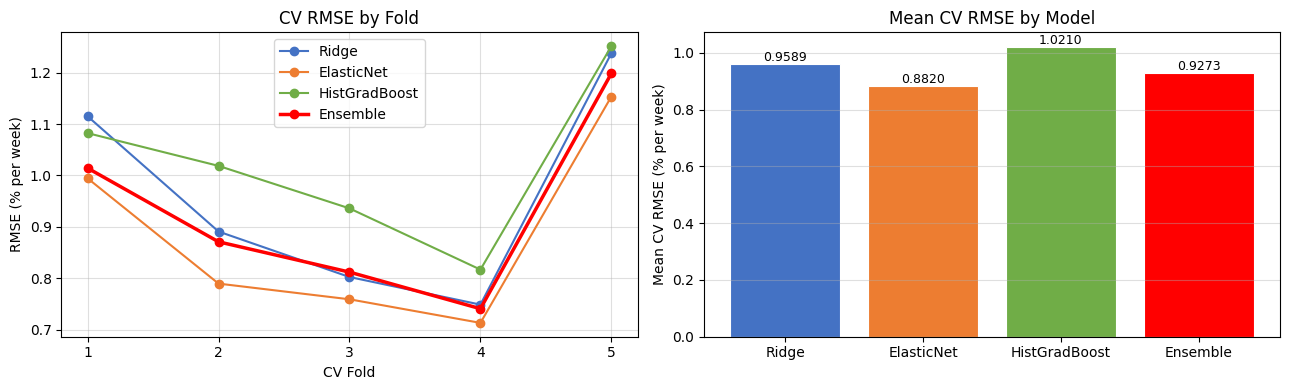

Saved: cv_rmse.png


In [79]:
# ── CV RMSE plot by fold ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
colors = {"Ridge": "#4472C4", "ElasticNet": "#ED7D31", "HistGradBoost": "#70AD47", "Ensemble": "#FF0000"}
n_folds = 5

for name, rmses in cv_results.items():
    ax1.plot(range(1, n_folds + 1), rmses, marker="o", label=name,
             color=colors[name], linewidth=2.5 if name == "Ensemble" else 1.5,
             zorder=5 if name == "Ensemble" else 3)

ax1.set_xlabel("CV Fold")
ax1.set_ylabel("RMSE (% per week)")
ax1.set_title("CV RMSE by Fold")
ax1.legend()
ax1.grid(True, alpha=0.4)
ax1.set_xticks(range(1, n_folds + 1))

# Bar chart of mean CV RMSE
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
bar_colors = [colors[n] for n in names]
bars = ax2.bar(names, means, color=bar_colors, edgecolor="white", linewidth=0.8)
ax2.set_ylabel("Mean CV RMSE (% per week)")
ax2.set_title("Mean CV RMSE by Model")
ax2.grid(True, axis="y", alpha=0.4)
for bar, val in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "cv_rmse.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cv_rmse.png")

<a id="phase-6"></a>
## Phase 6 — OOS Prediction Generation

**Goal:** Apply the fitted ensemble to the 52-week OOS window and write `predictions.txt`.

**Steps:**
1. Predict on `X_oos` (468 rows = 52 weeks × 9 countries)
2. Pivot to a 52 × 9 matrix — rows are Fridays, columns are countries in `CIDS_DM` order
3. Sanity-check the predictions (scale, sign, missing values)
4. Write `predictions.txt` — tab-delimited, no index, header row with country codes

In [80]:
# ── Generate OOS predictions ───────────────────────────────────────────────────
# X_oos is already in the right shape: 468 rows × 40 features (52 weeks × 9 countries)
# The panel rows are in (cid, real_date) order from Phase 4 — we need to attach
# the date/country metadata to pivot correctly.

oos_meta = df_panel.loc[oos_mask, ["real_date", "cid"]].reset_index(drop=True)
X_oos_reset = X_oos.reset_index(drop=True)

y_pred_flat = ensemble.predict(X_oos_reset)

df_pred = oos_meta.copy()
df_pred["prediction"] = y_pred_flat

print(f"Raw predictions shape : {df_pred.shape}  (should be 468 × 3)")
print(f"Weeks covered         : {df_pred['real_date'].nunique()}  (should be 52)")
print(f"Countries covered     : {sorted(df_pred['cid'].unique())}")
print(f"\nSample predictions (first 9 rows = week 1):")
print(df_pred.head(9).to_string(index=False))

Raw predictions shape : (468, 3)  (should be 468 × 3)
Weeks covered         : 52  (should be 52)
Countries covered     : ['AUD', 'CAD', 'CHF', 'EUR', 'GBP', 'JPY', 'NOK', 'SEK', 'USD']

Sample predictions (first 9 rows = week 1):
 real_date cid  prediction
2025-03-21 AUD    0.036922
2025-03-28 AUD    0.055799
2025-04-04 AUD    0.469594
2025-04-11 AUD    0.000703
2025-04-18 AUD   -0.070076
2025-04-25 AUD   -0.055445
2025-05-02 AUD   -0.078824
2025-05-09 AUD    0.029995
2025-05-16 AUD   -0.042175


Prediction matrix shape : (52, 9)  (should be 52 × 9)
Date range              : 2025-03-21 → 2026-03-13
Missing values          : 0

Extreme predictions (outside mean ± 5σ): 0

Prediction distribution per country (% per week):
cid        USD      EUR      GBP      JPY      AUD      CAD      CHF      SEK      NOK
count  52.0000  52.0000  52.0000  52.0000  52.0000  52.0000  52.0000  52.0000  52.0000
mean    0.1732   0.0016   0.0358  -0.0638  -0.0476  -0.0156   0.0944  -0.0371   0.0113
std     0.1417   0.1180   0.1103   0.0827   0.1061   0.0296   0.0950   0.1131   0.1176
min     0.0230  -0.1672  -0.1057  -0.1778  -0.2277  -0.0758  -0.0179  -0.2618  -0.1864
5%      0.0444  -0.1063  -0.0662  -0.1596  -0.2115  -0.0631   0.0131  -0.1648  -0.1635
25%     0.0982  -0.0489  -0.0186  -0.1239  -0.1005  -0.0389   0.0362  -0.0913  -0.0482
50%     0.1289  -0.0112   0.0156  -0.0780  -0.0566  -0.0125   0.0764  -0.0543  -0.0075
75%     0.2029   0.0235   0.0638  -0.0193   0.0105   0.0028   0.1252   0.0115

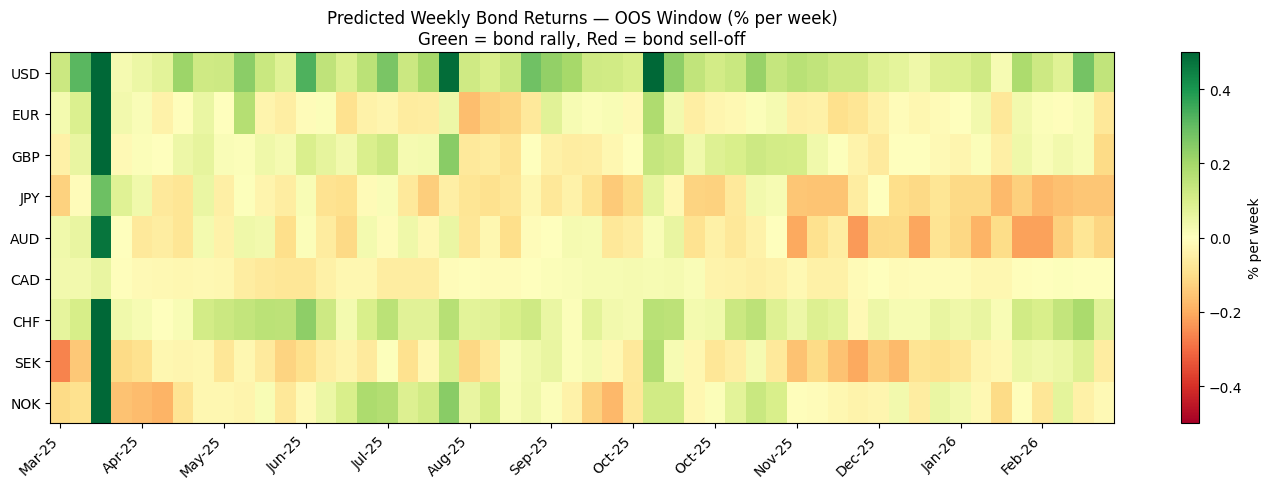

Saved: predictions_heatmap.png


In [81]:
# ── Pivot to 52 × 9 matrix and sanity-check ────────────────────────────────────
df_pred_matrix = (
    df_pred
    .pivot(index="real_date", columns="cid", values="prediction")
    .reindex(columns=CIDS_DM)   # enforce column order; NaN if a country is missing
)
df_pred_matrix.index = pd.to_datetime(df_pred_matrix.index)

print(f"Prediction matrix shape : {df_pred_matrix.shape}  (should be 52 × 9)")
print(f"Date range              : {df_pred_matrix.index[0].date()} → {df_pred_matrix.index[-1].date()}")
print(f"Missing values          : {df_pred_matrix.isnull().sum().sum()}")

# Scale check: weekly DU10YXR_NSA returns are typically in the range ±2%
# Flag predictions outside [mean ± 5σ] of the training distribution
train_std  = y_train.std()
train_mean = y_train.mean()
extreme_mask = (
    (df_pred_matrix < train_mean - 5 * train_std) |
    (df_pred_matrix > train_mean + 5 * train_std)
)
print(f"\nExtreme predictions (outside mean ± 5σ): {extreme_mask.sum().sum()}")

print(f"\nPrediction distribution per country (% per week):")
desc = df_pred_matrix.describe(percentiles=[0.05, 0.25, 0.75, 0.95]).round(4)
print(desc.to_string())

# Plot: predicted weekly returns heatmap over the 52-week OOS window
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(df_pred_matrix.T.values, aspect="auto", cmap="RdYlGn", vmin=-0.5, vmax=0.5)
ax.set_yticks(range(len(CIDS_DM)))
ax.set_yticklabels(df_pred_matrix.T.index.tolist())   # use actual index, not hardcoded list
ax.set_xticks(range(0, 52, 4))
ax.set_xticklabels([d.strftime("%b-%y") for d in df_pred_matrix.index[::4]], rotation=45, ha="right")
ax.set_title("Predicted Weekly Bond Returns — OOS Window (% per week)\nGreen = bond rally, Red = bond sell-off")
plt.colorbar(im, ax=ax, label="% per week")
plt.tight_layout()
plt.savefig(PROJECT_DIR / "predictions_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: predictions_heatmap.png")

In [82]:
# ── Write predictions.txt ──────────────────────────────────────────────────────
# Format: tab-delimited, header row = country codes, 52 data rows, no date index.
# Values are weekly DU10YXR_NSA returns (% per week), rounded to 6 decimal places.

PREDICTIONS_PATH = PROJECT_DIR / "predictions.txt"

df_pred_matrix.round(6).to_csv(
    PREDICTIONS_PATH,
    sep    = "\t",
    index  = False,
    header = True,
)

# Verify the output
with open(PREDICTIONS_PATH) as f:
    lines = f.readlines()

print(f"predictions.txt written: {PREDICTIONS_PATH}")
print(f"Lines: {len(lines)}  (1 header + 52 data rows = 53 expected)")
print(f"\nFirst 3 lines:")
for line in lines[:3]:
    print(" ", line.rstrip())
print(f"\nLast 2 lines:")
for line in lines[-2:]:
    print(" ", line.rstrip())


predictions.txt written: /Users/yunliu/projects/jpmaqs/predictions.txt
Lines: 53  (1 header + 52 data rows = 53 expected)

First 3 lines:
  USD	EUR	GBP	JPY	AUD	CAD	CHF	SEK	NOK
  0.128023	0.028484	-0.046305	-0.127866	0.036922	0.03216	0.063741	-0.261788	-0.105544
  0.315253	0.092491	0.056398	-0.011195	0.055799	0.031958	0.103157	-0.146751	-0.093123

Last 2 lines:
  0.277265	0.018141	0.016793	-0.150841	-0.080297	0.002849	0.189443	0.082336	-0.045231
  0.144585	-0.072275	-0.105719	-0.152	-0.119424	0.000475	0.076706	-0.055189	-0.015961


<a id="phase-7"></a>
## Phase 7 — Diagnostics & Economic Rationales

**Goal:** Validate model behaviour and generate evidence for the 3-page PDF rationale.

**Sections:**
1. **Residual analysis** — out-of-fold training residuals: are errors random, or systematic by regime/country?
2. **Feature importance** — which macro variables drive the model? Do they align with economic theory?
3. **Directional accuracy** — does the model get the sign right more often than chance? (More useful than RMSE for a practitioner)
4. **OOS actuals vs predictions** — compare predictions to realised returns where available

  Fold 1: train=1,545  test=1,581  rows excluded from OOF=7,905
  Fold 2: train=3,126  test=1,581  rows excluded from OOF=6,324
  Fold 3: train=4,707  test=1,581  rows excluded from OOF=4,743
  Fold 4: train=6,288  test=1,581  rows excluded from OOF=3,162
  Fold 5: train=7,869  test=1,581  rows excluded from OOF=1,581

OOF rows used : 7,905 of 9,486 training rows

OOF residual stats:
  Mean  : -0.2253  (close to 0 = no systematic bias)
  Std   : 0.9141
  Skew  : -0.1830
  Kurt  : 1.8640  (>0 = fat tails)


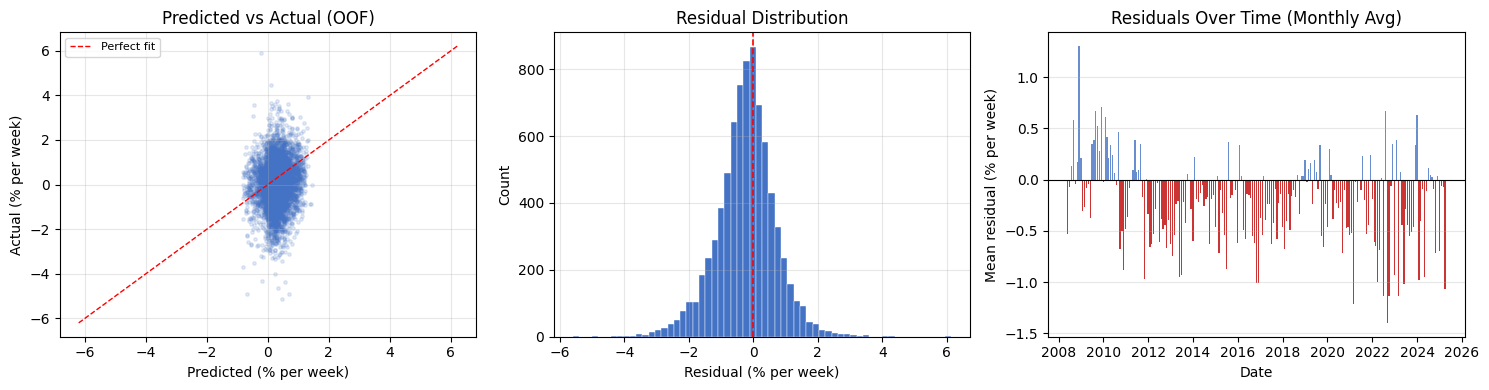


Mean residual by country (should all be near 0):
       mean     std
cid                
AUD -0.1245  1.0331
CAD -0.1639  0.9957
CHF -0.2083  0.7581
EUR -0.2734  0.8904
GBP -0.3069  1.0055
JPY -0.1278  0.4544
NOK -0.3497  0.8585
SEK -0.2596  0.9029
USD -0.2136  1.1325


In [83]:
# ── 7.1 Out-of-fold residual analysis ─────────────────────────────────────────
# cross_val_predict requires every row to appear in exactly one test fold.
# TimeSeriesSplit with a gap leaves the earliest rows out of all test folds,
# so cross_val_predict raises "only works for partitions".
# Fix: manually loop through folds, fill predictions only for test-fold rows.
from sklearn.base import clone

oof_preds = np.full(len(X_cv), np.nan)
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_cv)):
    fold_model = clone(ensemble)
    fold_model.fit(X_cv.iloc[train_idx], y_cv.iloc[train_idx])
    oof_preds[test_idx] = fold_model.predict(X_cv.iloc[test_idx])
    print(f"  Fold {fold+1}: train={len(train_idx):,}  test={len(test_idx):,}  "
          f"rows excluded from OOF={np.isnan(oof_preds).sum():,}")

oof_mask  = ~np.isnan(oof_preds)
residuals = y_cv.values[oof_mask] - oof_preds[oof_mask]

# Attach dates and countries for disaggregated analysis
resid_df = train_df[oof_mask][["real_date", "cid"]].copy().reset_index(drop=True)
resid_df["actual"]    = y_cv.values[oof_mask]
resid_df["predicted"] = oof_preds[oof_mask]
resid_df["residual"]  = residuals

print(f"\nOOF rows used : {oof_mask.sum():,} of {len(X_cv):,} training rows")
print(f"\nOOF residual stats:")
print(f"  Mean  : {residuals.mean():.4f}  (close to 0 = no systematic bias)")
print(f"  Std   : {residuals.std():.4f}")
print(f"  Skew  : {pd.Series(residuals).skew():.4f}")
print(f"  Kurt  : {pd.Series(residuals).kurt():.4f}  (>0 = fat tails)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Predicted vs actual scatter
ax = axes[0]
ax.scatter(resid_df["predicted"], resid_df["actual"], alpha=0.15, s=6, color="#4472C4")
lim = max(abs(resid_df["actual"]).max(), abs(resid_df["predicted"]).max()) * 1.05
ax.plot([-lim, lim], [-lim, lim], "r--", linewidth=1, label="Perfect fit")
ax.set_xlabel("Predicted (% per week)")
ax.set_ylabel("Actual (% per week)")
ax.set_title("Predicted vs Actual (OOF)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2. Residual distribution
ax = axes[1]
ax.hist(residuals, bins=60, color="#4472C4", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", linewidth=1.2, linestyle="--")
ax.set_xlabel("Residual (% per week)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.grid(True, alpha=0.3)

# 3. Residuals over time (monthly mean to reduce noise)
ax = axes[2]
resid_ts = resid_df.set_index("real_date")["residual"].resample("ME").mean()
ax.bar(resid_ts.index, resid_ts.values, width=20,
       color=["#C00000" if v < 0 else "#4472C4" for v in resid_ts.values], alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Date")
ax.set_ylabel("Mean residual (% per week)")
ax.set_title("Residuals Over Time (Monthly Avg)")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# Residuals by country — check for systematic country bias
print("\nMean residual by country (should all be near 0):")
print(resid_df.groupby("cid")["residual"].agg(["mean", "std"]).round(4).to_string())

Ridge alpha selected : 194.1492

Top 15 Ridge features (|coefficient| on scaled features):
EQXR_NSA            0.1215
DU05YCRY_NSA        0.0991
DU02YCRY_NSA        0.0698
carry_slope         0.0695
EQXR_NSA_csz        0.0621
CPIH_SA_P1M1ML12    0.0597
CPIC_SA_P1M1ML12    0.0549
cid_CHF             0.0539
ryld_spread         0.0489
PCREDITGDP_SA       0.0479
INFE1Y_JA           0.0457
cid_EUR             0.0441
RYLDIRS05Y_NSA      0.0410
cid_USD             0.0408
EQXR_mom4w          0.0388

Top 15 HGB features (permutation importance, neg-MSE drop):
EQXR_NSA             0.0887
DU02YCRY_NSA         0.0641
DU05YCRY_NSA         0.0616
EQXR_NSA_csz         0.0386
carry_slope          0.0356
EQXR_mom4w           0.0306
DU10YCRY_NSA         0.0294
MBASEGDP_SA          0.0251
RGDP_SA_P1Q1QL1AR    0.0239
RYLDIRS02Y_NSA       0.0226
INFTEFF_NSA          0.0212
infl_surprise        0.0205
CPIC_SA_P1M1ML12     0.0194
ryld_spread          0.0188
PCREDITGDP_SA        0.0171


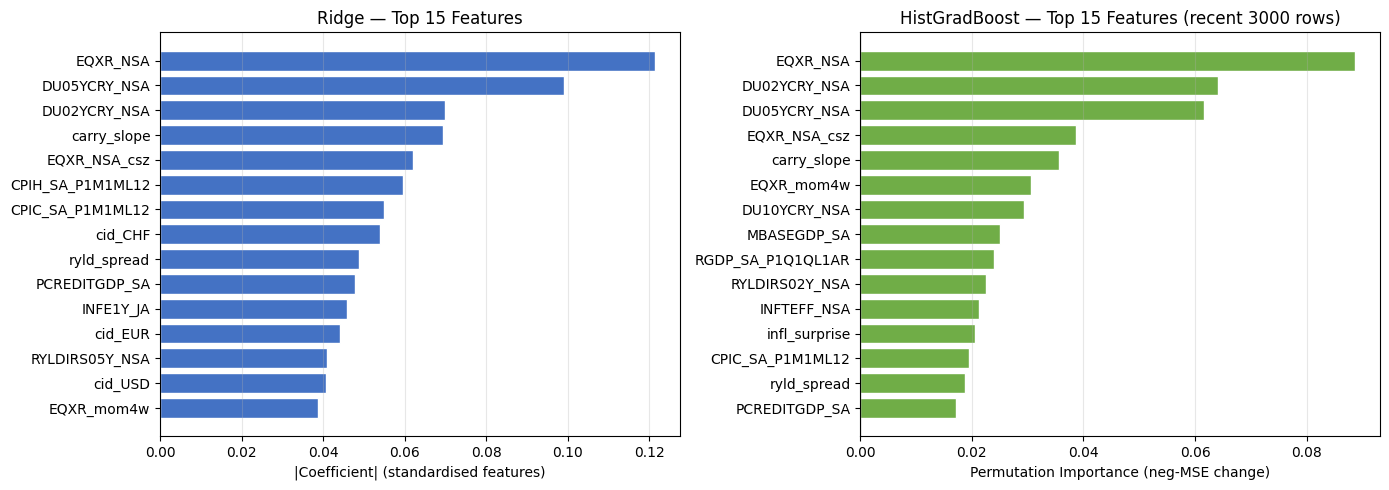

Saved: feature_importance.png


In [84]:
# ── 7.2 Feature importance ────────────────────────────────────────────────────
# Ridge: coefficients on standardised features — directly comparable in magnitude.
# HGB:   HistGradientBoostingRegressor has no feature_importances_ attribute.
#        Use permutation importance instead: shuffle each feature, measure RMSE
#        increase. Larger drop = more important. Works for any estimator.
#        Use the most recent N rows (not random) to reflect the current regime.
from sklearn.inspection import permutation_importance

TOP_N = 15

# Ridge coefficients (estimator index 0)
ridge_pipe = ensemble.estimators_[0]
ridge_coef = ridge_pipe.named_steps["model"].coef_
ridge_imp  = pd.Series(np.abs(ridge_coef), index=feature_cols).sort_values(ascending=False)

# HGB permutation importance (estimator index 2)
# Use the most recent 3000 rows — preserves temporal structure and reflects
# the regime closest to the OOS window (random sampling would break time order).
hgb_pipe    = ensemble.estimators_[2]
n_sample    = min(3000, len(X_cv))
X_recent    = X_cv.iloc[-n_sample:]
y_recent    = y_cv.iloc[-n_sample:]
perm_result = permutation_importance(
    hgb_pipe,
    X_recent,
    y_recent,
    n_repeats    = 10,
    scoring      = "neg_mean_squared_error",
    random_state = RANDOM_STATE,
    n_jobs       = -1,
)
hgb_imp = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

print(f"Ridge alpha selected : {ridge_pipe.named_steps['model'].alpha_:.4f}")
print(f"\nTop {TOP_N} Ridge features (|coefficient| on scaled features):")
print(ridge_imp.head(TOP_N).round(4).to_string())
print(f"\nTop {TOP_N} HGB features (permutation importance, neg-MSE drop):")
print(hgb_imp.head(TOP_N).round(4).to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Ridge
top_ridge = ridge_imp.head(TOP_N)[::-1]
ax1.barh(top_ridge.index, top_ridge.values, color="#4472C4", edgecolor="white")
ax1.set_xlabel("|Coefficient| (standardised features)")
ax1.set_title(f"Ridge — Top {TOP_N} Features")
ax1.grid(True, axis="x", alpha=0.3)

# HGB — permutation importance can be negative (feature adds noise)
top_hgb = hgb_imp.head(TOP_N)[::-1]
colors_hgb = ["#70AD47" if v >= 0 else "#C00000" for v in top_hgb.values]
ax2.barh(top_hgb.index, top_hgb.values, color=colors_hgb, edgecolor="white")
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Permutation Importance (neg-MSE change)")
ax2.set_title(f"HistGradBoost — Top {TOP_N} Features (recent {n_sample} rows)")
ax2.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance.png")


OOF Directional Accuracy (training) : 54.5%
  (naive baseline = 50.0%)

By country:
cid
CHF    0.577
JPY    0.575
EUR    0.549
AUD    0.538
CAD    0.536
GBP    0.536
NOK    0.532
SEK    0.532
USD    0.526

OOS weeks with actual data : 52 of 52
OOS Directional Accuracy   : 57.9%
OOS RMSE                   : 0.6880 % per week


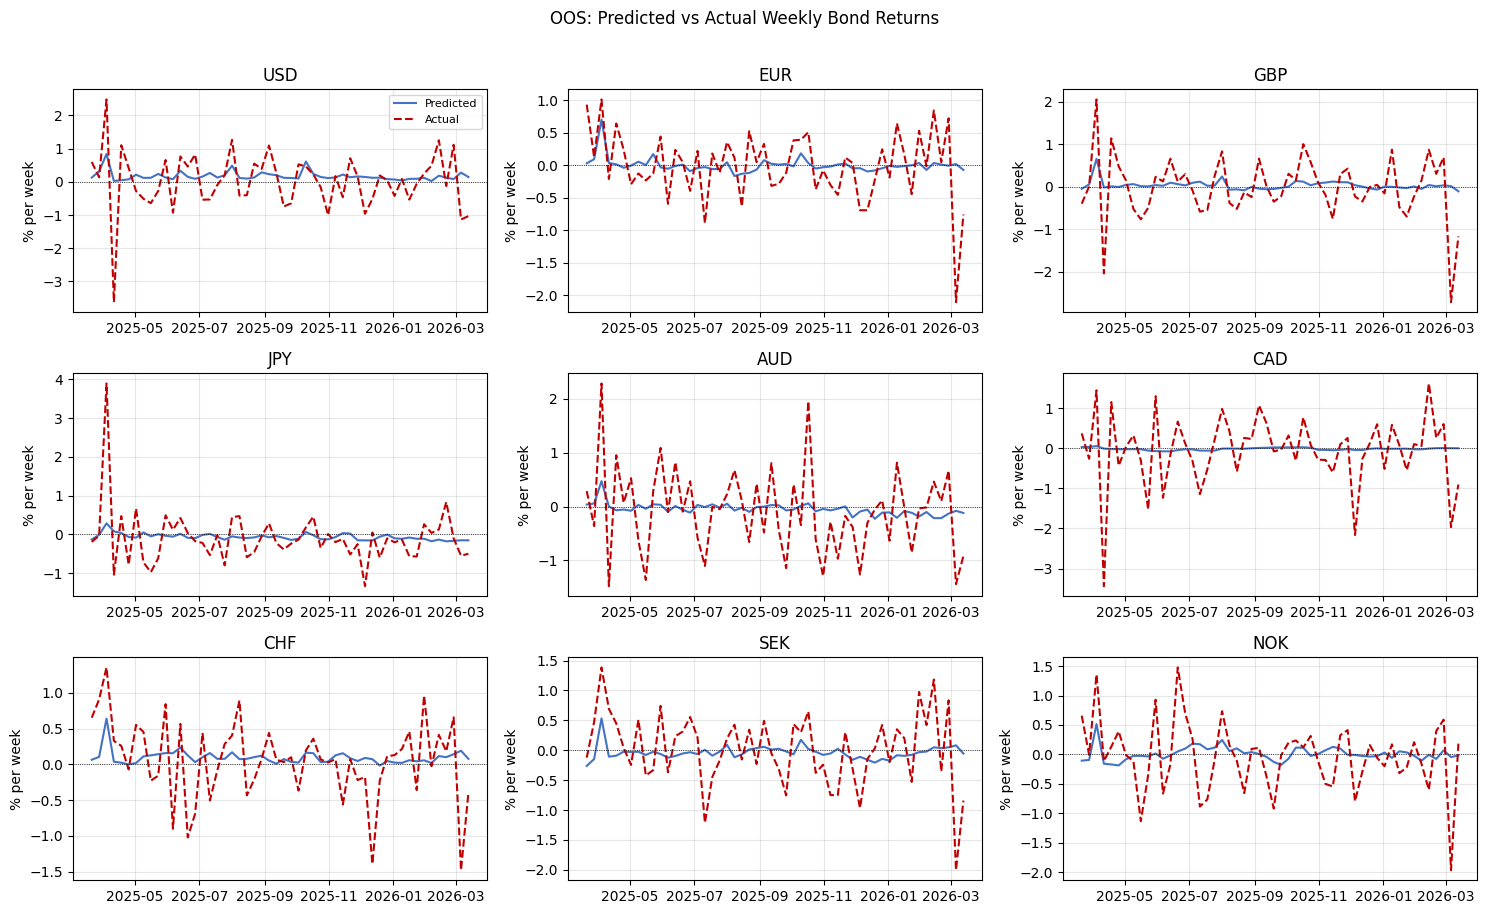

Saved: oos_vs_actual.png


In [85]:
# ── 7.3 Directional accuracy & OOS actuals vs predictions ─────────────────────
# Directional accuracy = % of weeks where sign(predicted) == sign(actual).
# A naive model that always predicts 0 gets 50% — our threshold for "useful".

# ── Training OOF directional accuracy ─────────────────────────────────────────
valid_train = resid_df.dropna(subset=["actual", "predicted"])
valid_train = valid_train[valid_train["actual"] != 0]   # exclude flat weeks

dir_correct = np.sign(valid_train["predicted"]) == np.sign(valid_train["actual"])
oof_da      = dir_correct.mean()
print(f"OOF Directional Accuracy (training) : {oof_da:.1%}")
print(f"  (naive baseline = 50.0%)")

print(f"\nBy country:")
da_by_cid = valid_train.groupby("cid").apply(
    lambda g: (np.sign(g["predicted"]) == np.sign(g["actual"])).mean()
).sort_values(ascending=False)
print(da_by_cid.round(3).to_string())

# ── OOS actuals vs predictions ─────────────────────────────────────────────────
# y_oos contains actual values where the cached data covers the OOS window.
oos_eval = df_panel.loc[oos_mask, ["real_date", "cid"]].copy().reset_index(drop=True)
oos_eval["actual"]    = y_oos.values
oos_eval["predicted"] = y_pred_flat   # from Phase 6
oos_eval["residual"]  = oos_eval["actual"] - oos_eval["predicted"]

oos_valid = oos_eval.dropna(subset=["actual"])
print(f"\nOOS weeks with actual data : {oos_valid['real_date'].nunique()} of 52")

if len(oos_valid) > 0:
    oos_da = (np.sign(oos_valid["predicted"]) == np.sign(oos_valid["actual"])).mean()
    oos_rmse = np.sqrt((oos_valid["residual"] ** 2).mean())
    print(f"OOS Directional Accuracy   : {oos_da:.1%}")
    print(f"OOS RMSE                   : {oos_rmse:.4f} % per week")

    # Plot OOS predictions vs actuals per country (small multiples)
    n_cols = 3
    n_rows = -(-len(CIDS_DM) // n_cols)   # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3), sharey=False)
    axes = axes.flatten()

    for i, cid in enumerate(CIDS_DM):
        ax   = axes[i]
        data = oos_eval[oos_eval["cid"] == cid].sort_values("real_date")
        ax.plot(data["real_date"], data["predicted"], label="Predicted",
                color="#4472C4", linewidth=1.5)
        actual_data = data.dropna(subset=["actual"])
        if len(actual_data) > 0:
            ax.plot(actual_data["real_date"], actual_data["actual"], label="Actual",
                    color="#C00000", linewidth=1.5, linestyle="--")
        ax.axhline(0, color="black", linewidth=0.6, linestyle=":")
        ax.set_title(cid)
        ax.set_ylabel("% per week")
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.legend(fontsize=8)

    for j in range(i + 1, len(axes)):   # hide unused subplots
        axes[j].set_visible(False)

    plt.suptitle("OOS: Predicted vs Actual Weekly Bond Returns", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(PROJECT_DIR / "oos_vs_actual.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: oos_vs_actual.png")
else:
    print("No OOS actual data available yet — plot skipped.")

In [86]:
# ── 7.4 Naive baseline & per-model OOS RMSE ───────────────────────────────────
# Two sanity checks:
# 1. Naive RMSE: always predict zero — if our model can't beat this, it adds no value.
#    Naive RMSE = sqrt(mean(actual^2)) = roughly std(actual) when mean(actual) ≈ 0.
# 2. Per-model OOS RMSE: compare each base learner individually against the ensemble.

oos_actuals = oos_valid["actual"].values

# ── 1. Naive baseline ─────────────────────────────────────────────────────────
naive_rmse  = np.sqrt(np.mean(oos_actuals ** 2))   # predict-zero RMSE
actual_std  = np.std(oos_actuals)                   # unconditional volatility
ens_rmse    = np.sqrt(np.mean(oos_valid["residual"].values ** 2))

print("── OOS Baseline Comparison ──────────────────────────────────────────────")
print(f"  Naive RMSE  (always predict 0) : {naive_rmse:.4f} % per week")
print(f"  Actual std  (OOS volatility)   : {actual_std:.4f} % per week")
print(f"  Ensemble RMSE                  : {ens_rmse:.4f} % per week")
print(f"  Skill vs naive (RMSE reduction): {(1 - ens_rmse / naive_rmse)*100:.1f}%")
print()

# ── 2. Per-model OOS RMSE ────────────────────────────────────────────────────
# ensemble.estimators_ contains the fitted base models in the order they were added.
# Use the same X_oos_reset and oos_valid index to align predictions with actuals.
oos_idx = oos_valid.index   # positional index into oos_eval

model_names = ["Ridge", "ElasticNet", "HistGradBoost"]
print("── Per-Model OOS RMSE ───────────────────────────────────────────────────")
print(f"  {'Model':<16} {'OOS RMSE':>10}  {'vs Naive':>10}  {'vs Ensemble':>12}")
print("  " + "-" * 52)

per_model_rmse = {}
for name, fitted_pipe in zip(model_names, ensemble.estimators_):
    preds = fitted_pipe.predict(X_oos_reset)
    preds_valid = preds[oos_valid.index]
    res = oos_actuals - preds_valid
    rmse = np.sqrt(np.mean(res ** 2))
    per_model_rmse[name] = rmse
    skill   = (1 - rmse / naive_rmse) * 100
    vs_ens  = rmse - ens_rmse
    print(f"  {name:<16} {rmse:>10.4f}  {skill:>9.1f}%  {vs_ens:>+12.4f}")

print(f"  {'Ensemble':<16} {ens_rmse:>10.4f}  {(1 - ens_rmse/naive_rmse)*100:>9.1f}%  {'0.0000':>12}")
print("  " + "-" * 52)
print(f"  {'Naive (predict 0)':<16} {naive_rmse:>10.4f}  {'0.0%':>10}  {naive_rmse - ens_rmse:>+12.4f}")


── OOS Baseline Comparison ──────────────────────────────────────────────
  Naive RMSE  (always predict 0) : 0.7135 % per week
  Actual std  (OOS volatility)   : 0.7131 % per week
  Ensemble RMSE                  : 0.6880 % per week
  Skill vs naive (RMSE reduction): 3.6%

── Per-Model OOS RMSE ───────────────────────────────────────────────────
  Model              OOS RMSE    vs Naive   vs Ensemble
  ----------------------------------------------------
  Ridge                0.6941        2.7%       +0.0061
  ElasticNet           0.7023        1.6%       +0.0144
  HistGradBoost        0.6879        3.6%       -0.0000
  Ensemble             0.6880        3.6%        0.0000
  ----------------------------------------------------
  Naive (predict 0)     0.7135        0.0%       +0.0256


<a id="phase-8"></a>
## Phase 8 — Hypothesis Tests
## H4 — Does Model Skill Concentrate in Large Moves?

**Question:** Is the 57.9% overall OOS directional accuracy uniform across all weeks, or does it concentrate in large moves (which matter economically) while being near-random on small moves? 

**Hypothesis:** 
1. H4a(quartile test):
  - Null: directional accuracy is uniform across move magnitude quartiles. 
  - Alternative: Q4 (largest moves) directional accuracy > Q1 (smallest moves) accuracy. 

2. H4b (threshold test):                                     
  - Null: higher |predicted| has no relationship with directional accuracy.  
  - Alternative: directional accuracy rises as |predicted| threshold rises. 
  
**Design:**
1. Split OOS observations into quartiles by actual move magnitude
2. Compute directional accuracy within each quartile
3. Test a threshold strategy: only act when |predicted| exceeds a threshold — does abstaining on low-conviction weeks raise accuracy?

**Implication:** If Q4 (largest moves) accuracy >> Q1 (smallest moves) accuracy, the model captures macro-driven structural repricing but not weekly noise — which is the right failure mode for a fundamentals-based model. 

OOS observations used        : 468
Overall directional accuracy : 57.9%  (sanity check vs Phase 7.3)

Directional accuracy by actual move magnitude quartile:
                 n  dir_acc  mean_move_pct
quartile                                  
Q1 (smallest)  117   0.5556         0.0940
Q2             117   0.6068         0.2759
Q3             117   0.5128         0.5147
Q4 (largest)   117   0.6410         1.1549

Q4 vs Q1 gap : +8.5pp

Threshold strategy (act when |predicted| > threshold, abstain otherwise):
 threshold  n_active  coverage  dir_acc
      0.00       468     1.000   0.5791
      0.05       263     0.562   0.6008
      0.10       137     0.293   0.5912
      0.15        65     0.139   0.6615
      0.20        30     0.064   0.7000
      0.25        16     0.034   0.8750
      0.30        11     0.024   1.0000

Best threshold : 0.30%  → 100.0% accuracy on 2% of observations


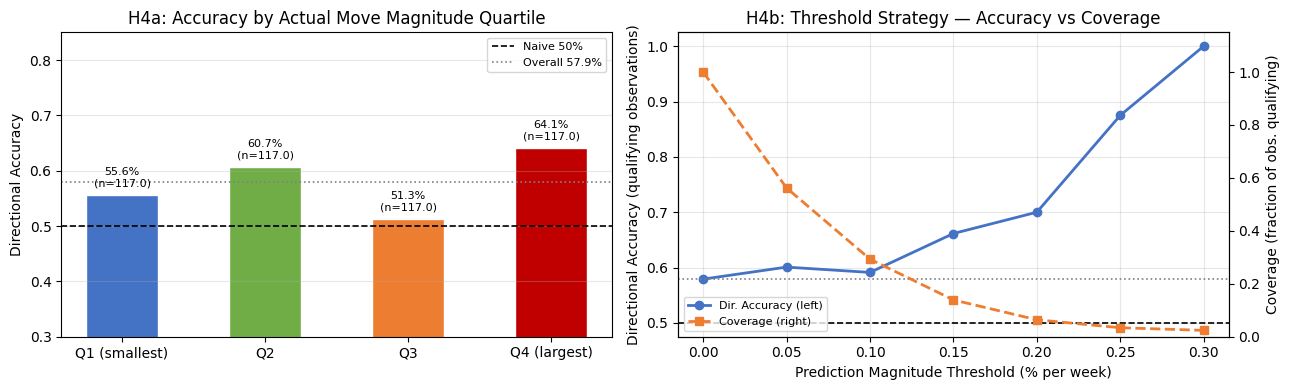

Saved: h4_large_move_accuracy.png


In [87]:
# ── H4: Directional accuracy by move magnitude + threshold  ────────────

# The threshold T is a scalar in the same units as the predicted variable (% per week).
# I tested T = 0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30% per week, each one filtering out small predicted and keep only the weeks when the model made large predicted. 

# This hypothesis cannot establish whether the large moves are driven by macroeconomic events. 
# Uses oos_eval (built in Phase 7.3): columns real_date, cid, actual, predicted


oos_h4 = oos_eval.dropna(subset=["actual"]).copy()
oos_h4 = oos_h4[oos_h4["actual"] != 0].reset_index(drop=True)
oos_h4["correct"]    = np.sign(oos_h4["predicted"]) == np.sign(oos_h4["actual"])
oos_h4["abs_actual"] = oos_h4["actual"].abs()
oos_h4["abs_pred"]   = oos_h4["predicted"].abs()

overall_da = oos_h4["correct"].mean()
print(f"OOS observations used        : {len(oos_h4)}")
print(f"Overall directional accuracy : {overall_da:.1%}  (sanity check vs Phase 7.3)")

# ── H4a: Accuracy by magnitude quartile ──────────────────────────────────────
oos_h4["quartile"] = pd.qcut(
    oos_h4["abs_actual"], q=4,
    labels=["Q1 (smallest)", "Q2", "Q3", "Q4 (largest)"]
)

q_stats = oos_h4.groupby("quartile", observed=True).agg(
    n             = ("correct", "count"),
    dir_acc       = ("correct", "mean"),
    mean_move_pct = ("abs_actual", "mean"),
).round(4)

print("\nDirectional accuracy by actual move magnitude quartile:")
print(q_stats.to_string())

q1_acc = q_stats.loc["Q1 (smallest)", "dir_acc"]
q4_acc = q_stats.loc["Q4 (largest)",  "dir_acc"]
print(f"\nQ4 vs Q1 gap : {(q4_acc - q1_acc)*100:+.1f}pp")

# ── H4b: Threshold strategy ───────────────────────────────────────────────────
thresholds = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
thresh_rows = []
for t in thresholds:
    mask = oos_h4["abs_pred"] > t
    n    = mask.sum()
    if n == 0:
        continue
    thresh_rows.append({
        "threshold": t,
        "n_active":  n,
        "coverage":  round(n / len(oos_h4), 3),
        "dir_acc":   round(oos_h4.loc[mask, "correct"].mean(), 4),
    })

thresh_df = pd.DataFrame(thresh_rows)
print("\nThreshold strategy (act when |predicted| > threshold, abstain otherwise):")
print(thresh_df.to_string(index=False))

best = thresh_df.loc[thresh_df["dir_acc"].idxmax()]
print(f"\nBest threshold : {best['threshold']:.2f}%  "
      f"→ {best['dir_acc']:.1%} accuracy on {best['coverage']:.0%} of observations")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ["#4472C4", "#70AD47", "#ED7D31", "#C00000"]
bars = ax1.bar(q_stats.index, q_stats["dir_acc"], color=colors, edgecolor="white", width=0.5)
ax1.axhline(0.5,        color="black", linestyle="--", linewidth=1.2, label="Naive 50%")
ax1.axhline(overall_da, color="grey",  linestyle=":",  linewidth=1.2,
            label=f"Overall {overall_da:.1%}")
ax1.set_ylabel("Directional Accuracy")
ax1.set_title("H4a: Accuracy by Actual Move Magnitude Quartile")
ax1.set_ylim(0.3, 0.85)
ax1.legend(fontsize=8)
ax1.grid(True, axis="y", alpha=0.3)
for bar, (_, row) in zip(bars, q_stats.iterrows()):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.012,
             f"{row['dir_acc']:.1%}\n(n={row['n']:,})",
             ha="center", va="bottom", fontsize=8)

ax2.plot(thresh_df["threshold"], thresh_df["dir_acc"],
         marker="o", color="#4472C4", linewidth=2, label="Dir. Accuracy (left)")
ax2.axhline(0.5,        color="black", linestyle="--", linewidth=1.2)
ax2.axhline(overall_da, color="grey",  linestyle=":",  linewidth=1.2)
ax2.set_xlabel("Prediction Magnitude Threshold (% per week)")
ax2.set_ylabel("Directional Accuracy (qualifying observations)")
ax2.set_title("H4b: Threshold Strategy — Accuracy vs Coverage")
ax2.grid(True, alpha=0.3)
ax_r = ax2.twinx()
ax_r.plot(thresh_df["threshold"], thresh_df["coverage"],
          marker="s", color="#ED7D31", linewidth=2, linestyle="--", label="Coverage (right)")
ax_r.set_ylabel("Coverage (fraction of obs. qualifying)")
ax_r.set_ylim(0, 1.15)
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax_r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc="lower left")

plt.tight_layout()
plt.savefig(PROJECT_DIR / "h4_large_move_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: h4_large_move_accuracy.png")

In [88]:
# ── Quartile bounds: return % and approximate yield change (bps) ──────────────
DURATION = 8  # approximate modified duration of a 10Y bond (years)


quartile_bounds = (
    oos_h4.groupby('quartile', observed=True)['abs_actual']
    .agg(lower='min', upper='max', mean='mean')
    .round(4)
)
quartile_bounds['lower_bps'] = (quartile_bounds['lower'] / DURATION * 100).round(1)
quartile_bounds['upper_bps'] = (quartile_bounds['upper'] / DURATION * 100).round(1)
quartile_bounds['mean_bps']  = (quartile_bounds['mean']  / DURATION * 100).round(1)

print(f'Quartile bounds of |actual weekly return| (duration assumption: {DURATION}y)\n')
print(f"{'Quartile':<18} {'Lower %':>8} {'Upper %':>8} {'Mean %':>8} "
      f"{'Lower bps':>10} {'Upper bps':>10} {'Mean bps':>10}")
print('-' * 78)
for q, row in quartile_bounds.iterrows():
    print(f'{str(q):<18} {row["lower"]:>8.4f} {row["upper"]:>8.4f} {row["mean"]:>8.4f} '
          f'{row["lower_bps"]:>10.1f} {row["upper_bps"]:>10.1f} {row["mean_bps"]:>10.1f}')


Quartile bounds of |actual weekly return| (duration assumption: 8y)

Quartile            Lower %  Upper %   Mean %  Lower bps  Upper bps   Mean bps
------------------------------------------------------------------------------
Q1 (smallest)        0.0034   0.1817   0.0940        0.0        2.3        1.2
Q2                   0.1825   0.3883   0.2759        2.3        4.9        3.4
Q3                   0.3921   0.6626   0.5147        4.9        8.3        6.4
Q4 (largest)         0.6646   3.8952   1.1549        8.3       48.7       14.4


In [89]:
# ── Significance tests for H4a and H4b ───────────────────────────────────────
from scipy import stats


p0 = overall_da  # null: accuracy in subset = overall accuracy

# ── H4a: one-proportion z-test per quartile ───────────────────────────────────
# H0: accuracy in quartile = p0
# H1 (two-tailed): accuracy != p0
# H1 (one-tailed, directional): Q4 > Q1
print('── H4a Significance Tests ──────────────────────────────────────────────────')
print(f'Null: accuracy = overall accuracy ({p0:.3f})')
print(f'{"Quartile":<18} {"n":>5} {"Acc":>7} {"z":>7} {"p (2-tail)":>11} {"p (1-tail >p0)":>15} {"Sig?":>6}')
print('-' * 75)

q_results = {}
for q, row in q_stats.iterrows():
    n     = int(row['n'])
    p_hat = row['dir_acc']
    se    = (p0 * (1 - p0) / n) ** 0.5
    z     = (p_hat - p0) / se
    p2    = 2 * (1 - stats.norm.cdf(abs(z)))
    p1    = 1 - stats.norm.cdf(z)
    sig   = '**' if p2 < 0.05 else ('*' if p2 < 0.10 else '')
    print(f'{str(q):<18} {n:>5} {p_hat:>7.3f} {z:>7.3f} {p2:>11.3f} {p1:>15.3f} {sig:>6}')
    q_results[q] = {'n': n, 'p_hat': p_hat, 'z': z, 'p2': p2}

# Q4 vs Q1: two-proportion z-test (one-tailed: H1: Q4 > Q1)
n4    = int(q_stats.loc['Q4 (largest)',  'n'])
n1    = int(q_stats.loc['Q1 (smallest)', 'n'])
p4    = q_stats.loc['Q4 (largest)',  'dir_acc']
p1_q  = q_stats.loc['Q1 (smallest)', 'dir_acc']
p_pool  = (p4 * n4 + p1_q * n1) / (n4 + n1)
se_diff = (p_pool * (1 - p_pool) * (1/n4 + 1/n1)) ** 0.5
z_diff  = (p4 - p1_q) / se_diff
p_diff  = 1 - stats.norm.cdf(z_diff)
print(f'\nQ4 vs Q1 (one-tailed, H1: Q4 > Q1):')
print(f'  z = {z_diff:.3f},  p = {p_diff:.3f}  '
      f'{"** significant at 5%" if p_diff < 0.05 else "* marginal (10%)" if p_diff < 0.10 else "not significant"}')

# ── H4b: one-proportion z-test per threshold + Bonferroni correction ─────────
# 'qualifying' = observations whose |predicted| exceeds threshold T
n_col   = 'n_qualifying' if 'n_qualifying' in thresh_df.columns else 'n_active'
n_tests = len(thresh_df)
print(f'\n── H4b Significance Tests ──────────────────────────────────────────────────')
print(f'Null: accuracy among qualifying observations = p0 ({p0:.3f})')
print(f'Bonferroni correction for {n_tests} thresholds (adjusted alpha = {0.05/n_tests:.4f})')
print(f'{"T":>6} {"n qualifying":>13} {"Acc":>7} {"z":>7} {"p (1-tail)":>11} {"Bonf. p":>9} {"Sig?":>6}')
print('-' * 65)

for _, row in thresh_df.iterrows():
    n     = int(row[n_col])
    p_hat = row['dir_acc']
    se    = (p0 * (1 - p0) / n) ** 0.5
    z     = (p_hat - p0) / se
    p1    = 1 - stats.norm.cdf(z)
    p_adj = min(p1 * n_tests, 1.0)
    sig   = '**' if p_adj < 0.05 else ('*' if p_adj < 0.10 else '')
    print(f'{row["threshold"]:>6.2f} {n:>13} {p_hat:>7.3f} {z:>7.3f} {p1:>11.3f} {p_adj:>9.3f} {sig:>6}')


── H4a Significance Tests ──────────────────────────────────────────────────
Null: accuracy = overall accuracy (0.579)
Quartile               n     Acc       z  p (2-tail)  p (1-tail >p0)   Sig?
---------------------------------------------------------------------------
Q1 (smallest)        117   0.556  -0.514       0.607           0.696       
Q2                   117   0.607   0.608       0.543           0.272       
Q3                   117   0.513  -1.452       0.147           0.927       
Q4 (largest)         117   0.641   1.357       0.175           0.087       

Q4 vs Q1 (one-tailed, H1: Q4 > Q1):
  z = 1.332,  p = 0.091  * marginal (10%)

── H4b Significance Tests ──────────────────────────────────────────────────
Null: accuracy among qualifying observations = p0 (0.579)
Bonferroni correction for 7 thresholds (adjusted alpha = 0.0071)
     T  n qualifying     Acc       z  p (1-tail)   Bonf. p   Sig?
-----------------------------------------------------------------
  0.00       

**H4 Results**

Key findings 

1. Descriptively, directional accuracy increases with weekly bond return magnitude (Q4 = 64.1%, Q1 = 55.6%), and Q3 is the anomalous low at 51.3%. However, none of these differences are statistically significant at 5%. 
2. In H4b test, directional accuracy rises as threshold increases. reaching 87.5% at T=0.25 and 100% at T=0.30. But the only statistically significant threshold after Bonferroni correction are where n ≤ 16, which is too small to be meaningful. 
3. In conclusion, we fail to reject te null hypothesis and cannot distinguish whether it's explainable by 1) the null is true or 2) the alternative is true but the test lacks statistical power to detect it. Therefore, even though that the results are directionally consistent with both alternatives, that larger weekly returns and higher predictions are both associated with higher directional accuracy, neither can be established statistically given the OOS window (52 week x 9 country) constraint. 


Implications 

1. Effect size and power should be estimated before running the test using Cohen's h. (specify the minimum meaningful difference and compute the required n before the test)
2. The OOS window is a structural constraint we need to work around. 

## Remaining Hypothesis Tests (Prioritized) ##
1. H1 — cross-sectional vs time-series signal decomposition
2. H5 — JPY structural break (pooled vs post-2022 JPY-only model) (Question: what's the advantage and disadvantage of using a pooled panel model vs. forecast saparately? )
3. H2 — monetary policy regime-conditionality 

## Ensemble Redesign — Action 1: Drop ElasticNet, Test Ridge + HGB

**Motivation:** HGB alone matched the full ensemble OOS RMSE (0.6879% vs 0.6880%), meaning ElasticNet adds no OOS value and may introduce regime sensitivity.

**Design:** Average predictions from the already-fitted Ridge and HGB estimators (no retraining needed — both were fitted on the full training set inside the original VotingRegressor).

**Evaluation:** Same OOS window and metrics as Phase 7.4 — RMSE, RMSE skill over naive, and directional accuracy.

In [90]:
# ── Action 1: Ridge + HGB ensemble (ElasticNet dropped) ───────────────────────
# ensemble.estimators_ order: [Ridge(0), ElasticNet(1), HGB(2)]
# Both were fitted on the full training set inside the original VotingRegressor.
fitted_ridge = ensemble.estimators_[0]
fitted_hgb   = ensemble.estimators_[2]

# Predict on OOS features
ridge_oos = fitted_ridge.predict(X_oos_reset)
hgb_oos   = fitted_hgb.predict(X_oos_reset)
rh_oos    = (ridge_oos + hgb_oos) / 2   # equal-weight average

# Align with oos_valid (subset with non-null actuals)
rh_valid    = rh_oos[oos_valid.index]
rh_residuals = oos_actuals - rh_valid
rh_rmse     = np.sqrt(np.mean(rh_residuals ** 2))
rh_skill    = (1 - rh_rmse / naive_rmse) * 100
rh_da       = (np.sign(rh_valid) == np.sign(oos_actuals)).mean()

# Individual model directional accuracy on OOS
ridge_da = (np.sign(ridge_oos[oos_valid.index]) == np.sign(oos_actuals)).mean()
hgb_da   = (np.sign(hgb_oos[oos_valid.index])   == np.sign(oos_actuals)).mean()
enet_da  = (np.sign(
    ensemble.estimators_[1].predict(X_oos_reset)[oos_valid.index]
) == np.sign(oos_actuals)).mean()

# ── Comparison table ─────────────────────────────────────────────────────────
print('── OOS Performance: Original Ensemble vs Redesigned Ridge + HGB ───────────')
print(f'{"Model":<42} {"RMSE":>8} {"RMSE Skill":>12} {"Dir. Acc":>10}')
print('-' * 76)
print(f'{"Naive (predict 0)":<42} {naive_rmse:>8.4f} {"0.0%":>12} {"50.0%":>10}')
print(f'{"Ridge alone":<42} {per_model_rmse["Ridge"]:>8.4f} '
      f'{(1 - per_model_rmse["Ridge"] / naive_rmse)*100:>11.1f}% {ridge_da:>10.1%}')
print(f'{"ElasticNet alone":<42} {per_model_rmse["ElasticNet"]:>8.4f} '
      f'{(1 - per_model_rmse["ElasticNet"] / naive_rmse)*100:>11.1f}% {enet_da:>10.1%}')
print(f'{"HGB alone":<42} {per_model_rmse["HistGradBoost"]:>8.4f} '
      f'{(1 - per_model_rmse["HistGradBoost"] / naive_rmse)*100:>11.1f}% {hgb_da:>10.1%}')
print('-' * 76)
print(f'{"Ridge + ElasticNet + HGB (original)":<42} {ens_rmse:>8.4f} '
      f'{(1 - ens_rmse / naive_rmse)*100:>11.1f}% {oos_da:>10.1%}')
print(f'{"Ridge + HGB (redesigned)":<42} {rh_rmse:>8.4f} '
      f'{rh_skill:>11.1f}% {rh_da:>10.1%}')
print('-' * 76)
print(f'\nRMSE change vs original ensemble : {(rh_rmse - ens_rmse):+.4f}% per week '
      f'({"improved" if rh_rmse < ens_rmse else "worsened"})')
print(f'Dir. accuracy change             : {(rh_da - oos_da)*100:+.1f}pp')


── OOS Performance: Original Ensemble vs Redesigned Ridge + HGB ───────────
Model                                          RMSE   RMSE Skill   Dir. Acc
----------------------------------------------------------------------------
Naive (predict 0)                            0.7135         0.0%      50.0%
Ridge alone                                  0.6941         2.7%      54.1%
ElasticNet alone                             0.7023         1.6%      51.5%
HGB alone                                    0.6879         3.6%      55.8%
----------------------------------------------------------------------------
Ridge + ElasticNet + HGB (original)          0.6880         3.6%      57.9%
Ridge + HGB (redesigned)                     0.6848         4.0%      57.7%
----------------------------------------------------------------------------

RMSE change vs original ensemble : -0.0032% per week (improved)
Dir. accuracy change             : -0.2pp


## Ensemble Redesign — Action 2: Add Monetary Policy Cycle Indicator

**Motivation:** Ridge and HGB currently infer the policy cycle implicitly from macro signals.
Adding an explicit regime indicator gives both models direct information about whether
markets are pricing in tightening or cutting, reducing their reliance on indirect inference.

**Features added:**
- `mp_cycle_own`: 4-week change in `RYLDIRS02Y_NSA` per country — idiosyncratic policy signal
- `mp_cycle_global`: cross-sectional mean of `mp_cycle_own` at each date — global cycle component

**Why continuous (not ternary):** no threshold to choose; both Ridge and HGB can learn
non-linear mappings from a continuous signal.

**Model:** Ridge + HGB only

**Hypothesis:** explicit regime context improves OOS RMSE and directional accuracy over the Action 1 baseline (Ridge + HGB without regime indicator).

In [91]:
# ── Action 2: Add monetary policy cycle indicator to Ridge + HGB ──────────────
# df_panel is sorted by (cid, real_date) from Phase 4 — correct for per-country diff

# mp_cycle_own: 4-week change in 2Y real yield IRS per country
# Positive = markets pricing in more tightening; negative = more cutting
df_panel["mp_cycle_own"] = (
    df_panel.groupby("cid")["RYLDIRS02Y_NSA"]
    .transform(lambda x: x.diff(4))
)

# mp_cycle_global: cross-sectional mean of mp_cycle_own at each date
# Captures the global DM policy cycle (all central banks moving together)
df_panel["mp_cycle_global"] = (
    df_panel.groupby("real_date")["mp_cycle_own"]
    .transform("mean")
)

new_regime_cols = ["mp_cycle_own", "mp_cycle_global"]
feature_cols_v2 = feature_cols + new_regime_cols

# Verify no look-ahead: new features depend only on data up to time t
print(f"New features added : {new_regime_cols}")
print(f"Total features v2  : {len(feature_cols_v2)}  (was {len(feature_cols)})")
print(f"NaN in mp_cycle_own    (train): "
      f"{df_panel.loc[train_mask, 'mp_cycle_own'].isnull().sum()}")
print(f"NaN in mp_cycle_global (train): "
      f"{df_panel.loc[train_mask, 'mp_cycle_global'].isnull().sum()}")

# ── Rebuild train / OOS matrices with new features ────────────────────────────
X_train_v2 = df_panel.loc[train_mask, feature_cols_v2]
X_oos_v2   = df_panel.loc[oos_mask,   feature_cols_v2].reset_index(drop=True)

# CV matrix: re-sort by (real_date, cid) for TimeSeriesSplit
train_df_v2 = df_panel.loc[train_mask].sort_values(["real_date", "cid"]).reset_index(drop=True)
X_cv_v2     = train_df_v2[feature_cols_v2]
y_cv_v2     = train_df_v2["y"]

print(f"\nX_train_v2 shape : {X_train_v2.shape}")
print(f"X_oos_v2 shape   : {X_oos_v2.shape}")

# ── Build and fit Ridge + HGB pipeline (fresh, unfitted copies) ───────────────
from sklearn.base import clone

pipe_ridge_v2 = clone(pipe_ridge)
pipe_hgb_v2   = clone(pipe_hgb)

ensemble_v2 = VotingRegressor(estimators=[
    ("ridge", pipe_ridge_v2),
    ("hgb",   pipe_hgb_v2),
])
ensemble_v2.fit(X_cv_v2, y_cv_v2)
print("\nensemble_v2 fitted on full training set")

# ── OOS evaluation ────────────────────────────────────────────────────────────
v2_preds_flat = ensemble_v2.predict(X_oos_v2)
v2_preds_valid = v2_preds_flat[oos_valid.index]
v2_residuals   = oos_actuals - v2_preds_valid
v2_rmse        = np.sqrt(np.mean(v2_residuals ** 2))
v2_skill       = (1 - v2_rmse / naive_rmse) * 100
v2_da          = (np.sign(v2_preds_valid) == np.sign(oos_actuals)).mean()

# ── Comparison table ─────────────────────────────────────────────────────────
print("\n── OOS Performance: Action 1 vs Action 2 ───────────────────────────────────")
print(f'{"Model":<45} {"RMSE":>8} {"RMSE Skill":>12} {"Dir. Acc":>10}')
print("-" * 79)
print(f'{"Naive (predict 0)":<45} {naive_rmse:>8.4f} {"0.0%":>12} {"50.0%":>10}')
print(f'{"Ridge + ElasticNet + HGB (original)":<45} {ens_rmse:>8.4f} '
      f'{(1 - ens_rmse / naive_rmse)*100:>11.1f}% {oos_da:>10.1%}')
print(f'{"Ridge + HGB (Action 1, no regime)":<45} {rh_rmse:>8.4f} '
      f'{rh_skill:>11.1f}% {rh_da:>10.1%}')
print(f'{"Ridge + HGB + mp_cycle (Action 2)":<45} {v2_rmse:>8.4f} '
      f'{v2_skill:>11.1f}% {v2_da:>10.1%}')
print("-" * 79)
print(f'\nRMSE change vs Action 1 : {(v2_rmse - rh_rmse):+.4f}% per week '
      f'({"improved" if v2_rmse < rh_rmse else "worsened"})')
print(f'Dir. accuracy change    : {(v2_da - rh_da)*100:+.1f}pp')


New features added : ['mp_cycle_own', 'mp_cycle_global']
Total features v2  : 42  (was 40)
NaN in mp_cycle_own    (train): 1086
NaN in mp_cycle_global (train): 36

X_train_v2 shape : (9486, 42)
X_oos_v2 shape   : (468, 42)

ensemble_v2 fitted on full training set

── OOS Performance: Action 1 vs Action 2 ───────────────────────────────────
Model                                             RMSE   RMSE Skill   Dir. Acc
-------------------------------------------------------------------------------
Naive (predict 0)                               0.7135         0.0%      50.0%
Ridge + ElasticNet + HGB (original)             0.6880         3.6%      57.9%
Ridge + HGB (Action 1, no regime)               0.6848         4.0%      57.7%
Ridge + HGB + mp_cycle (Action 2)               0.6393        10.4%      62.2%
-------------------------------------------------------------------------------

RMSE change vs Action 1 : -0.0455% per week (improved)
Dir. accuracy change    : +4.5pp



Strategy 5 — Risk Aversion Timing of Bond Positions                                                                                      

The thesis: in the current negative-beta regime (post-2000), bonds are maximally valuable as hedges when risk aversion is highest. So the trade is to buy bonds before stress peaks, not during.

Signal: VIX level, surplus consumption, or P/D ratio as proxies for risk aversion.

The concrete question to backtest: "Does buying 10-year Treasuries when VIX is above threshold X generate better risk-adjusted returns than holding bonds unconditionally, in the post-2000 negative-beta regime?

Why it's tractable: Data is freely available (VIX, S&P 500, 10-year Treasury), the mechanism is directly grounded in the Campbell/Pflueger/Viceira paper you worked on, and the backtest is straightforward to implement in Python.

The catch: Timing entry is hard — you're buying when things look bad but before they get worse. And the strategy breaks entirely if the regime flips positive (back toward 1970s-style supply shocks), which the paper's 2023-2025 data suggests is a real risk right now.

Ridge v2 alpha selected : 495.3535

Top 15 Ridge v2 features (|coefficient| on standardised features):
mp_cycle_own          0.1544
mp_cycle_global       0.1416
EQXR_NSA              0.1024
EQXR_mom4w            0.0678
DU05YCRY_NSA          0.0492
EQXR_NSA_csz          0.0427
DU10YCRY_NSA          0.0261
carry_slope           0.0243
ryld_spread           0.0212
cid_EUR               0.0205
INFE1Y_JA             0.0203
UNEMPLRATE_SA_3MMA    0.0200
PCREDITGDP_SA         0.0196
EQCRY_NSA             0.0181
MBASEGDP_SA           0.0177

Regime feature ranks (Ridge v2):
  mp_cycle_own              rank   1 of 42  coef=0.1544
  mp_cycle_global           rank   2 of 42  coef=0.1416

Top 15 HGB v2 features (permutation importance, recent 3000 rows):
mp_cycle_global      0.2472
mp_cycle_own         0.1028
EQXR_NSA             0.0627
EQXR_mom4w           0.0444
EQXR_NSA_csz         0.0345
infl_surprise        0.0295
DU05YCRY_NSA         0.0226
INFTEFF_NSA          0.0198
ryld_spread          0.0

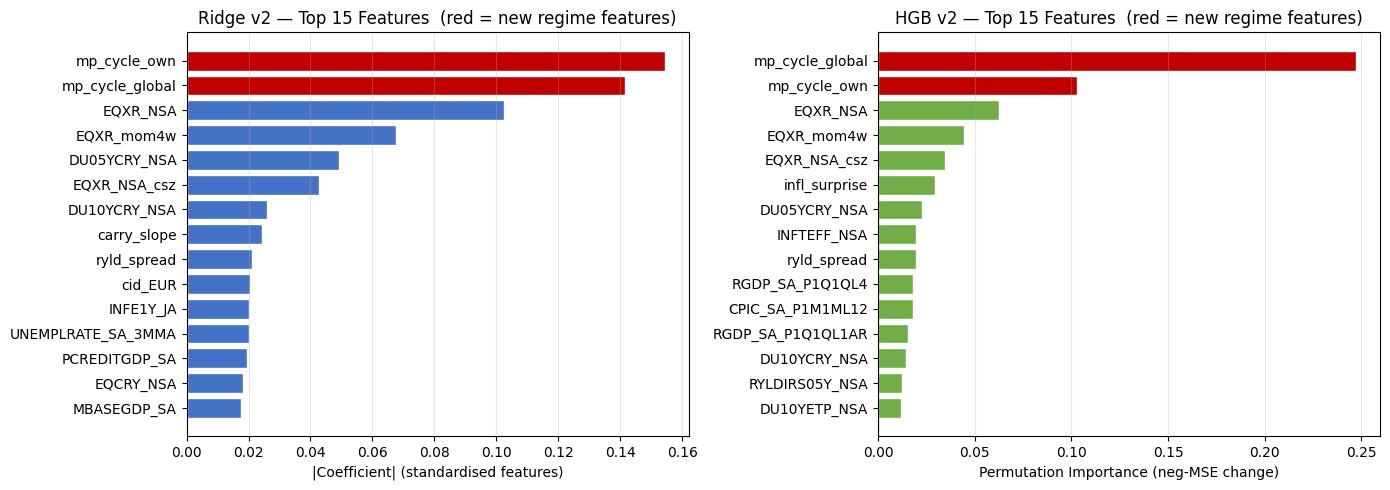

Saved: feature_importance_v2.png


In [92]:
# ── Action 2: Feature importance + per-model benefit analysis ─────────────────
# ensemble_v2.estimators_ order: [Ridge(0), HGB(1)]
from sklearn.inspection import permutation_importance

TOP_N      = 15
REGIME_COLS = ["mp_cycle_own", "mp_cycle_global"]

# ── Ridge v2: coefficients on standardised features ───────────────────────────
ridge_v2 = ensemble_v2.estimators_[0]
ridge_v2_coef = ridge_v2.named_steps["model"].coef_
ridge_v2_imp  = pd.Series(np.abs(ridge_v2_coef),
                          index=feature_cols_v2).sort_values(ascending=False)

print(f"Ridge v2 alpha selected : {ridge_v2.named_steps['model'].alpha_:.4f}")
print(f"\nTop {TOP_N} Ridge v2 features (|coefficient| on standardised features):")
print(ridge_v2_imp.head(TOP_N).round(4).to_string())

regime_ridge_ranks = {c: ridge_v2_imp.index.get_loc(c) + 1 for c in REGIME_COLS}
print(f"\nRegime feature ranks (Ridge v2):")
for c, r in regime_ridge_ranks.items():
    print(f"  {c:<25} rank {r:>3} of {len(feature_cols_v2)}  "
          f"coef={ridge_v2_imp[c]:.4f}")

# ── HGB v2: permutation importance (most recent 3000 rows) ────────────────────
hgb_v2    = ensemble_v2.estimators_[1]
n_sample  = min(3000, len(X_cv_v2))
X_rec_v2  = X_cv_v2.iloc[-n_sample:]
y_rec_v2  = y_cv_v2.iloc[-n_sample:]

perm_v2 = permutation_importance(
    hgb_v2, X_rec_v2, y_rec_v2,
    n_repeats=10, scoring="neg_mean_squared_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)
hgb_v2_imp = pd.Series(perm_v2.importances_mean,
                       index=feature_cols_v2).sort_values(ascending=False)

print(f"\nTop {TOP_N} HGB v2 features (permutation importance, recent {n_sample} rows):")
print(hgb_v2_imp.head(TOP_N).round(4).to_string())

regime_hgb_ranks = {c: hgb_v2_imp.index.get_loc(c) + 1 for c in REGIME_COLS}
print(f"\nRegime feature ranks (HGB v2):")
for c, r in regime_hgb_ranks.items():
    print(f"  {c:<25} rank {r:>3} of {len(feature_cols_v2)}  "
          f"imp={hgb_v2_imp[c]:.4f}")

# ── Per-model OOS benefit: v1 (40 features) vs v2 (42 features) ───────────────
print("\n── Per-model OOS RMSE: Action 1 vs Action 2 ────────────────────────────────")
print(f'{"Model":<30} {"Action 1 RMSE":>14} {"Action 2 RMSE":>14} {"Change":>10}')
print("-" * 72)

# Action 1: individual predictions from original ensemble estimators
ridge_v1_preds  = fitted_ridge.predict(X_oos_reset)[oos_valid.index]
hgb_v1_preds    = fitted_hgb.predict(X_oos_reset)[oos_valid.index]

# Action 2: individual predictions from ensemble_v2 estimators
ridge_v2_preds_oos = ensemble_v2.estimators_[0].predict(X_oos_v2)[oos_valid.index]
hgb_v2_preds_oos   = ensemble_v2.estimators_[1].predict(X_oos_v2)[oos_valid.index]

for label, v1_p, v2_p in [
    ("Ridge",       ridge_v1_preds, ridge_v2_preds_oos),
    ("HGB",         hgb_v1_preds,   hgb_v2_preds_oos),
]:
    r1 = np.sqrt(np.mean((oos_actuals - v1_p) ** 2))
    r2 = np.sqrt(np.mean((oos_actuals - v2_p) ** 2))
    print(f"{label:<30} {r1:>14.4f} {r2:>14.4f} {(r2-r1):>+10.4f}")

print(f'{"Ridge + HGB ensemble":<30} {rh_rmse:>14.4f} {v2_rmse:>14.4f} '
      f'{(v2_rmse - rh_rmse):>+10.4f}')

# ── Plot: feature importance comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge v2
top_r = ridge_v2_imp.head(TOP_N)[::-1]
colors_r = ["#C00000" if c in REGIME_COLS else "#4472C4" for c in top_r.index]
axes[0].barh(top_r.index, top_r.values, color=colors_r, edgecolor="white")
axes[0].set_xlabel("|Coefficient| (standardised features)")
axes[0].set_title(f"Ridge v2 — Top {TOP_N} Features  (red = new regime features)")
axes[0].grid(True, axis="x", alpha=0.3)

# HGB v2
top_h = hgb_v2_imp.head(TOP_N)[::-1]
colors_h = ["#C00000" if c in REGIME_COLS
            else ("#70AD47" if v >= 0 else "#888888")
            for c, v in zip(top_h.index, top_h.values)]
axes[1].barh(top_h.index, top_h.values, color=colors_h, edgecolor="white")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Permutation Importance (neg-MSE change)")
axes[1].set_title(f"HGB v2 — Top {TOP_N} Features  (red = new regime features)")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_DIR / "feature_importance_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_v2.png")


Notes 

1. Why does 4-week difference in 2Y real yield IRS tell us about monetary policy cycle? Volocity of change? 

2. How does HGB and Ridge handle missing data differently? 

3. Solutions to the Japan Yield Curve Control (YCC) period 2016-2024 
    - Implement make_blacklist for JPY YCC, exclude entire observations of every feature for Japan from the training, so that the pooled model learns the normal non-intervenced macro relationships across the rest of the countries from the data. 

4. solutions to publication lag
    - Use eop_lag to forward-fill each feature based on its actual publication cycle: 
        1) daily indicators (IRS rate, equity returns)
        2) Monthly indicators (CPI, unemployment): fill up to 5–6 weeks until the next monthly release 
        3) Quarterly indicators (GDP): fill up to ~13 weeks because a new observation only arrives once per quarter 

5. Systematic approach to find bond-relevant features from the JPMaQS universe
    - Start from economic models (New Keynesian framework, SDF, and others) and map machanisms backwards to data 
        1) Real policy rate expectation 
            -  real 2-year rate expectation (RYLDIRS02Y_NSA)
        2) Inflation expectations
        3) Risk premium 
        4) Fiscal/suppy factors (?)
        5) Bond mometum and value 

    - Workflow to explore new features 
        1) choose an economic machanism 
        2) search the catolog 
        3) filter for coverage 
        4) run bivariate signal-return analysis 
        5) add in batches grouped by machanism 







## Verification — Ridge Coefficient Sign Audit

Ridge coefficients encode the direction of the linear relationship between each feature
and bond returns. Where economic theory gives a clear prediction, the estimated sign
should match. Mismatches warrant investigation: multicollinearity, non-linearity,
sign-convention issues, or incorrect economic logic.

**Sign convention:** `DU10YXR_NSA` (target) is positive when bonds rally (yields fall).
So a feature that predicts rising yields should have a **negative** coefficient.

In [93]:
# ── Ridge coefficient sign audit (ensemble_v2, 42 features) ───────────────────
# Target: DU10YXR_NSA = positive when bonds rally (yields fall)
# Expected signs derived from economic theory:
#   Negative: equity returns, inflation, inflation expectations, tightening signals
#   Positive: bond carry, unemployment (weak economy), monetary base (QE)
#   Ambiguous: real yield levels, GDP

EXPECTED_SIGNS = {
    # Bond carry — high carry = cheap bonds = mean-revert upward = positive return
    "DU02YCRY_NSA":          +1,
    "DU05YCRY_NSA":          +1,
    "DU10YCRY_NSA":          +1,
    "carry_slope":           +1,   # steep curve = long end cheap
    # Inflation — higher inflation = yields rise = negative return
    "CPIH_SA_P1M1ML12":      -1,
    "CPIC_SA_P1M1ML12":      -1,
    "INFE1Y_JA":             -1,
    "INFE5Y_JA":             -1,
    "infl_surprise":         -1,   # inflation above expectations = yields rise
    # Equity — equity up = risk-on = bonds sell off
    "EQXR_NSA":              -1,
    "EQXR_mom4w":            -1,   # sustained equity rally = bonds down
    "EQXR_NSA_csz":          -1,   # country equity outperformance = bonds down
    # Monetary policy cycle — tightening = yields rise = negative return
    "mp_cycle_own":          -1,
    "mp_cycle_global":       -1,
    # Labour market — high unemployment = weak economy = rate cuts ahead = bonds up
    "UNEMPLRATE_SA_3MMA":    +1,
    "UNEMPLRATE_SA_3MMAv5YMA": +1,
    # Monetary base — high/expanding = QE = bonds supported = positive return
    "MBASEGDP_SA":           +1,
    "MBASEGDP_SA_D1M1ML3":   +1,
    # Cross-sectional carry — above-average carry = country cheap = positive
    "DU10YCRY_NSA_csz":      +1,
    # Cross-sectional inflation — above-average inflation = yields rise = negative
    "CPIH_SA_P1M1ML12_csz": -1,
}

# Extract Ridge v2 coefficients WITH sign (not absolute value)
ridge_v2      = ensemble_v2.estimators_[0]
coef_raw      = ridge_v2.named_steps["model"].coef_
coef_series   = pd.Series(coef_raw, index=feature_cols_v2)

# Build audit table
rows = []
for feat, expected in EXPECTED_SIGNS.items():
    if feat not in coef_series.index:
        continue
    coef  = coef_series[feat]
    actual_sign = int(np.sign(coef))
    match = actual_sign == expected
    rows.append({
        "feature":       feat,
        "coefficient":   round(coef, 4),
        "actual_sign":   "+" if actual_sign > 0 else "-",
        "expected_sign": "+" if expected > 0 else "-",
        "match":         "✓" if match else "✗ MISMATCH",
    })

audit_df = pd.DataFrame(rows).sort_values("coefficient", key=abs, ascending=False)

print("── Ridge v2 Coefficient Sign Audit ─────────────────────────────────────────")
print(f"{'Feature':<30} {'Coef':>8} {'Actual':>8} {'Expected':>9} {'':>12}")
print("-" * 72)
for _, r in audit_df.iterrows():
    print(f"{r['feature']:<30} {r['coefficient']:>8.4f} "
          f"{r['actual_sign']:>8} {r['expected_sign']:>9} {r['match']:>12}")

n_match    = (audit_df["match"] == "✓").sum()
n_mismatch = (audit_df["match"] == "✗ MISMATCH").sum()
print(f"\nMatches: {n_match}/{len(audit_df)}   Mismatches: {n_mismatch}/{len(audit_df)}")

# ── All coefficients for reference ───────────────────────────────────────────
print("\n── All Ridge v2 Coefficients (sorted by magnitude) ─────────────────────────")
all_coef = coef_series.sort_values(key=abs, ascending=False)
for feat, val in all_coef.items():
    sign_str = "+" if val > 0 else "-"
    exp = EXPECTED_SIGNS.get(feat, "?")
    exp_str = "+" if exp == 1 else ("-" if exp == -1 else "?")
    flag = "" if exp == "?" else ("  ✓" if np.sign(val) == exp else "  ✗")
    print(f"  {feat:<35} {val:>8.4f}  [{sign_str}]  expected [{exp_str}]{flag}")


── Ridge v2 Coefficient Sign Audit ─────────────────────────────────────────
Feature                            Coef   Actual  Expected             
------------------------------------------------------------------------
mp_cycle_own                    -0.1544        -         -            ✓
mp_cycle_global                 -0.1416        -         -            ✓
EQXR_NSA                        -0.1024        -         -            ✓
EQXR_mom4w                       0.0678        +         -   ✗ MISMATCH
DU05YCRY_NSA                    -0.0492        -         +   ✗ MISMATCH
EQXR_NSA_csz                     0.0427        +         -   ✗ MISMATCH
DU10YCRY_NSA                     0.0261        +         +            ✓
carry_slope                      0.0243        +         +            ✓
INFE1Y_JA                       -0.0203        -         -            ✓
UNEMPLRATE_SA_3MMA               0.0200        +         +            ✓
MBASEGDP_SA                     -0.0177        -         +

## Forward-Lag Test — Verifying OOS Performance Is Genuine

**Motivation:** In our current setup X[t] predicts Y[t] (contemporaneous). Daily financial
features like IRS rates and equity returns move alongside bond returns within the same week,
driven by the same macro news. This could inflate OOS metrics.

**Test A:** Lag only `mp_cycle_own` and `mp_cycle_global` by 1 week → isolates whether
the regime indicator specifically is contemporaneous.

**Test B:** Lag all daily financial features (IRS rates, equity returns, regime) by 1 week
→ tests whether the issue is broader across all fast-moving features.

**Interpretation:** If skill collapses in Test A → regime features drove the improvement
through within-week co-movement, not genuine forecasting power. If skill holds → the
signal is forward-looking and robust.

In [94]:
# ── Forward-Lag Test ─────────────────────────────────────────────────────────
# df_panel is sorted by (cid, real_date) — correct for per-country shift
from sklearn.base import clone

DAILY_FIN_FEATURES = [
    "RYLDIRS02Y_NSA", "RYLDIRS05Y_NSA",
    "EQXR_NSA", "EQXR_mom4w", "EQXR_NSA_csz",
    "mp_cycle_own", "mp_cycle_global",
]

def build_lagged_features(base_cols, lag_cols):
    """Return a new feature column list with lag_cols replaced by their lag-1 versions."""
    out = []
    for f in base_cols:
        if f in lag_cols:
            lag_name = f + "_lag1"
            if lag_name not in df_panel.columns:
                df_panel[lag_name] = df_panel.groupby("cid")[f].transform(
                    lambda x: x.shift(1)
                )
            out.append(lag_name)
        else:
            out.append(f)
    return out

def run_ensemble(feature_cols_new, label):
    """Fit Ridge+HGB on training data and evaluate on OOS. Returns (rmse, skill, da)."""
    train_sorted = (
        df_panel.loc[train_mask]
        .sort_values(["real_date", "cid"])
        .reset_index(drop=True)
    )
    X_cv_new  = train_sorted[feature_cols_new]
    y_cv_new  = train_sorted["y"]
    X_oos_new = df_panel.loc[oos_mask, feature_cols_new].reset_index(drop=True)

    ens = VotingRegressor([
        ("ridge", clone(pipe_ridge)),
        ("hgb",   clone(pipe_hgb)),
    ])
    ens.fit(X_cv_new, y_cv_new)

    preds_valid = ens.predict(X_oos_new)[oos_valid.index]
    rmse  = np.sqrt(np.mean((oos_actuals - preds_valid) ** 2))
    skill = (1 - rmse / naive_rmse) * 100
    da    = (np.sign(preds_valid) == np.sign(oos_actuals)).mean()
    print(f"  {label:<45} RMSE={rmse:.4f}  Skill={skill:.1f}%  DA={da:.1%}")
    return rmse, skill, da

print("── Forward-Lag Tests ───────────────────────────────────────────────────────")
print(f"  {'Model':<45} {'RMSE':>8}  {'Skill':>7}  {'Dir.Acc':>8}")
print("-" * 75)

# Baseline: Action 2 (contemporaneous, for reference)
print(f"  {'Ridge+HGB+regime (Action 2, contemporaneous)':<45} "
      f"RMSE={v2_rmse:.4f}  Skill={v2_skill:.1f}%  DA={v2_da:.1%}")

# Test A: lag only regime features
cols_A = build_lagged_features(feature_cols_v2, ["mp_cycle_own", "mp_cycle_global"])
rmse_A, skill_A, da_A = run_ensemble(cols_A, "Test A: regime features lagged 1 week")

# Test B: lag all daily financial features
cols_B = build_lagged_features(feature_cols_v2, DAILY_FIN_FEATURES)
rmse_B, skill_B, da_B = run_ensemble(cols_B, "Test B: all daily features lagged 1 week")

print("-" * 75)
print(f"\nChange from Action 2 → Test A : RMSE skill {skill_A - v2_skill:+.1f}pp  "
      f"DA {(da_A - v2_da)*100:+.1f}pp")
print(f"Change from Action 2 → Test B : RMSE skill {skill_B - v2_skill:+.1f}pp  "
      f"DA {(da_B - v2_da)*100:+.1f}pp")

print("\nInterpretation:")
threshold = 3.0  # pp drop considered meaningful
if abs(skill_A - v2_skill) > threshold:
    print("  Test A: regime features are contemporaneous — "
          f"skill drops {skill_A - v2_skill:.1f}pp when lagged")
else:
    print("  Test A: regime signal is robust to 1-week lag — "
          "improvement is genuinely forward-looking")
if abs(skill_B - skill_A) > threshold:
    print("  Test B: other daily features also contribute contemporaneous inflation")
else:
    print("  Test B: contemporaneous issue is confined to regime features")


── Forward-Lag Tests ───────────────────────────────────────────────────────
  Model                                             RMSE    Skill   Dir.Acc
---------------------------------------------------------------------------
  Ridge+HGB+regime (Action 2, contemporaneous)  RMSE=0.6393  Skill=10.4%  DA=62.2%
  Test A: regime features lagged 1 week         RMSE=0.6942  Skill=2.7%  DA=57.1%
  Test B: all daily features lagged 1 week      RMSE=0.7051  Skill=1.2%  DA=57.7%
---------------------------------------------------------------------------

Change from Action 2 → Test A : RMSE skill -7.7pp  DA -5.1pp
Change from Action 2 → Test B : RMSE skill -9.2pp  DA -4.5pp

Interpretation:
  Test A: regime features are contemporaneous — skill drops -7.7pp when lagged
  Test B: contemporaneous issue is confined to regime features
